In [ ]:
# =====================================================================
# STEP 6
# INDEPENDENT BPDB CROSS-DATASET VALIDATION
#
# Primary goals:
#
# 1. Validate PGCB Evening_Peak observations against BPDB.
# 2. Validate Ridge forecasts against independent BPDB evening demand.
# 3. Quantify cross-source agreement and forecast transferability.
#
#
# IMPORTANT:
#
# BPDB Version 2 is used as the external validation source.
#
# We DO NOT use BPDB Version 5 because it includes later smoothing,
# imputation and normalization.
#
#
# Main PGCB-BPDB mapping:
#
# PGCB rows explicitly labelled:
#
#       remarks == "Evening_Peak"
#
# are preferred over assuming every evening peak occurs at 19:30.
#
#
# Run this entire code in ONE Google Colab cell.
# =====================================================================


# =====================================================================
# 0. IMPORT LIBRARIES
# =====================================================================

import os
import re
import json
import math
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    250
)

pd.set_option(
    "display.max_rows",
    200
)

pd.set_option(
    "display.width",
    260
)


print("=" * 115)

print(
    "STEP 6: INDEPENDENT BPDB CROSS-DATASET VALIDATION"
)

print("=" * 115)


# =====================================================================
# 1. MOUNT GOOGLE DRIVE
# =====================================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)


print(
    "\nGoogle Drive mounted successfully."
)


# =====================================================================
# 2. PROJECT DIRECTORIES
# =====================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


FORECAST_DIR = (
    PROJECT_ROOT
    / "data"
    / "forecasting"
)


STEP3_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml_baselines"
)


STEP5B_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "adaptive_conformal"
)


RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_bpdb_validation"
)


FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "external_bpdb_validation"
)


for directory in [

    RESULT_DIR,
    FIGURE_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. REQUIRED PGCB FILES
# =====================================================================

PGCB_AUDIT_FILE = (

    PROCESSED_DIR
    /
    "pgcb_all_rows_quality_flagged.csv"
)


PGCB_FINAL_HOURLY_FILE = (

    PROCESSED_DIR
    /
    "pgcb_final_observed_hourly_target.csv"
)


STEP3_PREDICTION_FILE = (

    STEP3_RESULT_DIR
    /
    "all_test_predictions.csv"
)


ADAPTIVE_INTERVAL_FILE = (

    STEP5B_RESULT_DIR
    /
    "primary_adaptive_90percent_intervals.csv"
)


for required_file in [

    PGCB_AUDIT_FILE,
    PGCB_FINAL_HOURLY_FILE,
    STEP3_PREDICTION_FILE

]:

    if not required_file.exists():

        raise FileNotFoundError(
            f"""
Required file not found:

{required_file}

Please confirm the previous steps completed successfully.
"""
        )


# =====================================================================
# 4. LOCATE BPDB VERSION 2 DATASET
# =====================================================================

# We search several likely locations.
#
# The preferred external dataset file is:
#
# version 2.xlsx
#
# We intentionally do not use Version 5.


search_roots = [

    PROJECT_ROOT,

    Path(
        "/content/drive/MyDrive"
    ),

    Path(
        "/content"
    )
]


bpdb_candidates = []


for root in search_roots:

    if not root.exists():

        continue


    try:

        for candidate in root.rglob(
            "*.xlsx"
        ):

            normalized_name = (

                candidate.name
                .lower()
                .replace(
                    "_",
                    " "
                )
                .replace(
                    "-",
                    " "
                )
            )


            normalized_path = (
                str(
                    candidate
                )
                .lower()
            )


            if (

                (
                    "version 2"
                    in
                    normalized_name
                )

                or

                (
                    "version2"
                    in
                    normalized_name
                )

            ):

                bpdb_candidates.append(
                    candidate
                )


    except Exception:

        pass


# Remove duplicates.

unique_candidates = []

seen_candidates = set()


for candidate in bpdb_candidates:

    candidate_string = str(
        candidate
    )


    if candidate_string not in seen_candidates:

        unique_candidates.append(
            candidate
        )

        seen_candidates.add(
            candidate_string
        )


bpdb_candidates = (
    unique_candidates
)


print("\nBPDB Version 2 candidates found:")


for index, candidate in enumerate(
    bpdb_candidates,
    start=1
):

    print(
        f"{index}. {candidate}"
    )


if len(
    bpdb_candidates
) == 0:

    raise FileNotFoundError(
        """
BPDB Version 2 Excel file was not found automatically.

Expected file name similar to:

version 2.xlsx

Please place the BPDB dataset inside:

/content/drive/MyDrive/Load_Forecasting_Paper/data/raw/

and rerun this cell.
"""
    )


# Prefer a path containing both "version 2" directory/file.

def candidate_score(
    path
):

    text = str(
        path
    ).lower()


    score = 0


    if "version 2" in text:

        score += 10


    if "structured" in text:

        score += 5


    if "electricity" in text:

        score += 3


    if "bpdb" in text:

        score += 3


    return score


bpdb_candidates = sorted(

    bpdb_candidates,

    key=
        candidate_score,

    reverse=True
)


BPDB_FILE = (
    bpdb_candidates[0]
)


print(
    "\nSelected BPDB Version 2 file:"
)

print(
    BPDB_FILE
)


# =====================================================================
# 5. LOAD BPDB VERSION 2
# =====================================================================

bpdb = pd.read_excel(
    BPDB_FILE
)


print("\nBPDB file loaded.")


print(
    "Rows:",
    len(
        bpdb
    )
)


print(
    "Columns:",
    len(
        bpdb.columns
    )
)


print(
    "\nBPDB columns:"
)


for index, column in enumerate(
    bpdb.columns
):

    print(
        index,
        ":",
        column
    )


# =====================================================================
# 6. NORMALIZE COLUMN NAMES FOR SEARCH
# =====================================================================

def normalize_column_name(
    value
):

    value = str(
        value
    ).strip().lower()


    value = re.sub(

        r"\s+",

        " ",

        value
    )


    return value


normalized_column_map = {

    normalize_column_name(
        column
    ):
        column

    for column in bpdb.columns
}


# =====================================================================
# 7. IDENTIFY BPDB DATE COLUMN
# =====================================================================

date_candidates = [

    column

    for column in bpdb.columns

    if normalize_column_name(
        column
    )
    in
    [
        "date",
        "dates"
    ]
]


if len(
    date_candidates
) == 0:

    date_candidates = [

        column

        for column in bpdb.columns

        if "date"
        in
        normalize_column_name(
            column
        )
    ]


if len(
    date_candidates
) == 0:

    raise ValueError(
        "Could not identify BPDB date column."
    )


BPDB_DATE_COLUMN = (
    date_candidates[0]
)


bpdb[
    BPDB_DATE_COLUMN
] = pd.to_datetime(

    bpdb[
        BPDB_DATE_COLUMN
    ],

    errors="coerce"
)


bpdb = (

    bpdb
    .dropna(
        subset=[
            BPDB_DATE_COLUMN
        ]
    )

    .sort_values(
        BPDB_DATE_COLUMN
    )

    .reset_index(
        drop=True
    )
)


bpdb[
    "date"
] = (

    bpdb[
        BPDB_DATE_COLUMN
    ]
    .dt.normalize()
)


print(
    "\nBPDB date column:",
    BPDB_DATE_COLUMN
)


print(
    "BPDB period:",
    bpdb[
        "date"
    ].min(),
    "to",
    bpdb[
        "date"
    ].max()
)


# =====================================================================
# 8. IDENTIFY BPDB NATIONAL EVENING-DEMAND COLUMNS
# =====================================================================

# Expected columns from prior audit:
#
# Max. Demand at eve. peak (Generation end)
# Max. Demand at eve. peak (Sub-station end)


generation_end_candidates = []


substation_end_candidates = []


for column in bpdb.columns:

    normalized = normalize_column_name(
        column
    )


    if (

        "demand"
        in normalized

        and

        (
            "eve"
            in normalized

            or

            "evening"
            in normalized
        )

        and

        "generation"
        in normalized

    ):

        generation_end_candidates.append(
            column
        )


    if (

        "demand"
        in normalized

        and

        (
            "eve"
            in normalized

            or

            "evening"
            in normalized
        )

        and

        (
            "sub"
            in normalized
        )

    ):

        substation_end_candidates.append(
            column
        )


print(
    "\nGeneration-end evening demand candidates:"
)

print(
    generation_end_candidates
)


print(
    "\nSubstation-end evening demand candidates:"
)

print(
    substation_end_candidates
)


if len(
    generation_end_candidates
) == 0:

    raise ValueError(
        """
Could not identify BPDB generation-end evening demand column.

Please send the printed BPDB column list to ChatGPT.
"""
    )


BPDB_EVENING_GENERATION_COLUMN = (
    generation_end_candidates[0]
)


if len(
    substation_end_candidates
) > 0:

    BPDB_EVENING_SUBSTATION_COLUMN = (
        substation_end_candidates[0]
    )

else:

    BPDB_EVENING_SUBSTATION_COLUMN = (
        None
    )


bpdb[
    "bpdb_evening_generation_mw"
] = pd.to_numeric(

    bpdb[
        BPDB_EVENING_GENERATION_COLUMN
    ],

    errors="coerce"
)


if (
    BPDB_EVENING_SUBSTATION_COLUMN
    is not None
):

    bpdb[
        "bpdb_evening_substation_mw"
    ] = pd.to_numeric(

        bpdb[
            BPDB_EVENING_SUBSTATION_COLUMN
        ],

        errors="coerce"
    )


print(
    "\nSelected generation-end column:"
)

print(
    BPDB_EVENING_GENERATION_COLUMN
)


if (
    BPDB_EVENING_SUBSTATION_COLUMN
    is not None
):

    print(
        "\nSelected substation-end column:"
    )

    print(
        BPDB_EVENING_SUBSTATION_COLUMN
    )


# =====================================================================
# 9. BASIC BPDB VALUE FILTER
# =====================================================================

# This is NOT data smoothing.
#
# It removes only impossible/non-numeric national-load entries
# for external matching.


bpdb.loc[

    ~bpdb[
        "bpdb_evening_generation_mw"
    ]
    .between(
        1000,
        30000
    ),

    "bpdb_evening_generation_mw"

] = np.nan


if (
    "bpdb_evening_substation_mw"
    in
    bpdb.columns
):

    bpdb.loc[

        ~bpdb[
            "bpdb_evening_substation_mw"
        ]
        .between(
            1000,
            30000
        ),

        "bpdb_evening_substation_mw"

    ] = np.nan


# =====================================================================
# 10. LOAD COMPLETE PGCB QUALITY-AUDIT DATA
# =====================================================================

pgcb_all = pd.read_csv(
    PGCB_AUDIT_FILE,
    low_memory=False
)


pgcb_all[
    "datetime"
] = pd.to_datetime(

    pgcb_all[
        "datetime"
    ],

    errors="coerce"
)


pgcb_all = (

    pgcb_all
    .dropna(
        subset=[
            "datetime"
        ]
    )

    .sort_values(
        "datetime"
    )

    .reset_index(
        drop=True
    )
)


pgcb_all[
    "date"
] = (

    pgcb_all[
        "datetime"
    ]
    .dt.normalize()
)


# =====================================================================
# 11. IDENTIFY DEMAND COLUMN IN PGCB
# =====================================================================

if (
    "demand_original"
    in
    pgcb_all.columns
):

    PGCB_DEMAND_COLUMN = (
        "demand_original"
    )


elif (
    "demand_mw"
    in
    pgcb_all.columns
):

    PGCB_DEMAND_COLUMN = (
        "demand_mw"
    )


else:

    raise ValueError(
        "Could not identify PGCB demand column."
    )


pgcb_all[
    PGCB_DEMAND_COLUMN
] = pd.to_numeric(

    pgcb_all[
        PGCB_DEMAND_COLUMN
    ],

    errors="coerce"
)


# =====================================================================
# 12. SAFE BOOLEAN HELPER
# =====================================================================

def safe_bool(
    series
):

    if pd.api.types.is_bool_dtype(
        series
    ):

        return series.fillna(
            False
        )


    return (

        series
        .astype(str)
        .str.strip()
        .str.lower()

        .map(
            {

                "true":
                    True,

                "false":
                    False,

                "1":
                    True,

                "0":
                    False
            }
        )

        .fillna(
            False
        )

        .astype(bool)
    )


if (
    "demand_corrupt"
    in
    pgcb_all.columns
):

    pgcb_all[
        "demand_corrupt"
    ] = safe_bool(

        pgcb_all[
            "demand_corrupt"
        ]
    )


else:

    pgcb_all[
        "demand_corrupt"
    ] = False


# =====================================================================
# 13. EXTRACT EXPLICIT PGCB EVENING_PEAK ROWS
# =====================================================================

if (
    "remarks"
    not in
    pgcb_all.columns
):

    raise ValueError(
        "PGCB remarks column is missing."
    )


pgcb_all[
    "remarks_clean"
] = (

    pgcb_all[
        "remarks"
    ]

    .fillna(
        ""
    )

    .astype(str)

    .str.strip()

    .str.lower()
)


explicit_evening = (

    pgcb_all.loc[

        pgcb_all[
            "remarks_clean"
        ]
        .eq(
            "evening_peak"
        )

        &

        (~pgcb_all[
            "demand_corrupt"
        ])

        &

        pgcb_all[
            PGCB_DEMAND_COLUMN
        ]
        .between(
            1000,
            30000
        )
    ]

    .copy()
)


print("\n" + "=" * 115)

print(
    "EXPLICIT PGCB EVENING_PEAK SERIES"
)

print("=" * 115)


print(
    "Rows:",
    len(
        explicit_evening
    )
)


print(
    "Period:",
    explicit_evening[
        "datetime"
    ].min(),
    "to",
    explicit_evening[
        "datetime"
    ].max()
)


# =====================================================================
# 14. EVENING_PEAK TIMESTAMP DISTRIBUTION
# =====================================================================

explicit_evening[
    "time_string"
] = (

    explicit_evening[
        "datetime"
    ]

    .dt.strftime(
        "%H:%M"
    )
)


evening_time_distribution = (

    explicit_evening[
        "time_string"
    ]

    .value_counts()

    .rename_axis(
        "time"
    )

    .reset_index(
        name="count"
    )
)


print(
    "\nExplicit Evening_Peak timestamp distribution:"
)


display(
    evening_time_distribution.head(30)
)


# =====================================================================
# 15. ONE EXPLICIT EVENING-PEAK VALUE PER DATE
# =====================================================================

# If multiple records occur on a date:
#
# choose the maximum reported Evening_Peak demand.
#
# This is transparent and avoids arbitrary timestamp selection.


pgcb_evening_daily = (

    explicit_evening

    .groupby(
        "date"
    )

    .agg(

        pgcb_evening_peak_mw=(
            PGCB_DEMAND_COLUMN,
            "max"
        ),

        pgcb_evening_peak_records=(
            PGCB_DEMAND_COLUMN,
            "size"
        )
    )

    .reset_index()
)


print(
    "\nUnique PGCB Evening_Peak dates:",
    len(
        pgcb_evening_daily
    )
)


# =====================================================================
# 16. LOAD CLEAN 23-SLOT PGCB DATA
# =====================================================================

pgcb_hourly = pd.read_csv(
    PGCB_FINAL_HOURLY_FILE,
    low_memory=False
)


pgcb_hourly[
    "datetime"
] = pd.to_datetime(

    pgcb_hourly[
        "datetime"
    ],

    errors="coerce"
)


pgcb_hourly = (

    pgcb_hourly
    .dropna(
        subset=[
            "datetime"
        ]
    )

    .sort_values(
        "datetime"
    )

    .reset_index(
        drop=True
    )
)


if (
    "demand_final"
    in
    pgcb_hourly.columns
):

    HOURLY_DEMAND_COLUMN = (
        "demand_final"
    )


elif (
    "demand_mw"
    in
    pgcb_hourly.columns
):

    HOURLY_DEMAND_COLUMN = (
        "demand_mw"
    )


else:

    raise ValueError(
        "Could not locate clean hourly demand column."
    )


pgcb_hourly[
    HOURLY_DEMAND_COLUMN
] = pd.to_numeric(

    pgcb_hourly[
        HOURLY_DEMAND_COLUMN
    ],

    errors="coerce"
)


pgcb_hourly[
    "date"
] = (

    pgcb_hourly[
        "datetime"
    ]
    .dt.normalize()
)


pgcb_hourly[
    "hour"
] = (

    pgcb_hourly[
        "datetime"
    ]
    .dt.hour
)


# =====================================================================
# 17. COMPUTE ACTUAL 23-SLOT DAILY PEAK
# =====================================================================

actual_daily_profile_peak = (

    pgcb_hourly.loc[

        pgcb_hourly[
            "hour"
        ]
        .between(
            1,
            23
        )
    ]

    .groupby(
        "date"
    )

    .agg(

        pgcb_23slot_peak_mw=(
            HOURLY_DEMAND_COLUMN,
            "max"
        ),

        available_slots=(
            "hour",
            "nunique"
        )
    )

    .reset_index()
)


# =====================================================================
# 18. COMPUTE ACTUAL EVENING-WINDOW MAX
# =====================================================================

# Secondary comparison only.
#
# 17:00-22:00 integer-hour observations.


actual_evening_window_peak = (

    pgcb_hourly.loc[

        pgcb_hourly[
            "hour"
        ]
        .between(
            17,
            22
        )
    ]

    .groupby(
        "date"
    )

    .agg(

        pgcb_evening_window_max_mw=(
            HOURLY_DEMAND_COLUMN,
            "max"
        )
    )

    .reset_index()
)


# =====================================================================
# 19. LOAD STEP 3 RIDGE PREDICTIONS
# =====================================================================

prediction_df = pd.read_csv(
    STEP3_PREDICTION_FILE,
    low_memory=False
)


prediction_df[
    "target_date"
] = pd.to_datetime(

    prediction_df[
        "target_date"
    ],

    errors="coerce"
)


prediction_df = (

    prediction_df
    .dropna(
        subset=[
            "target_date"
        ]
    )

    .sort_values(
        "target_date"
    )

    .reset_index(
        drop=True
    )
)


ridge_prediction_columns = [

    f"ridge_pred_h{hour:02d}"

    for hour in HOURS
]


missing_ridge_columns = [

    column

    for column in ridge_prediction_columns

    if column
    not in
    prediction_df.columns
]


if len(
    missing_ridge_columns
) > 0:

    raise ValueError(
        f"""
Ridge prediction columns missing:

{missing_ridge_columns}
"""
    )


# =====================================================================
# 20. DERIVE RIDGE PROFILE PEAK FORECAST
# =====================================================================

prediction_df[
    "ridge_profile_peak_mw"
] = (

    prediction_df[
        ridge_prediction_columns
    ]

    .max(
        axis=1
    )
)


prediction_df[
    "ridge_profile_peak_hour"
] = (

    prediction_df[
        ridge_prediction_columns
    ]

    .idxmax(
        axis=1
    )

    .str.extract(
        r"h(\d+)"
    )[0]

    .astype(int)
)


# =====================================================================
# 21. DERIVE RIDGE EVENING 17-22 PEAK FORECAST
# =====================================================================

ridge_evening_columns = [

    f"ridge_pred_h{hour:02d}"

    for hour in range(
        17,
        23
    )
]


prediction_df[
    "ridge_evening_peak_mw"
] = (

    prediction_df[
        ridge_evening_columns
    ]

    .max(
        axis=1
    )
)


prediction_df[
    "ridge_evening_peak_hour"
] = (

    prediction_df[
        ridge_evening_columns
    ]

    .idxmax(
        axis=1
    )

    .str.extract(
        r"h(\d+)"
    )[0]

    .astype(int)
)


prediction_df[
    "date"
] = (

    prediction_df[
        "target_date"
    ]
    .dt.normalize()
)


# =====================================================================
# 22. BUILD EXTERNAL VALIDATION MASTER TABLE
# =====================================================================

external = (

    bpdb[
        [
            "date",
            "bpdb_evening_generation_mw"
        ]
        +
        (
            [
                "bpdb_evening_substation_mw"
            ]

            if (
                "bpdb_evening_substation_mw"
                in
                bpdb.columns
            )

            else []
        )
    ]

    .merge(

        pgcb_evening_daily,

        on="date",

        how="left"
    )

    .merge(

        actual_daily_profile_peak,

        on="date",

        how="left"
    )

    .merge(

        actual_evening_window_peak,

        on="date",

        how="left"
    )

    .merge(

        prediction_df[
            [
                "date",

                "ridge_profile_peak_mw",

                "ridge_profile_peak_hour",

                "ridge_evening_peak_mw",

                "ridge_evening_peak_hour"
            ]
        ],

        on="date",

        how="left"
    )
)


print("\n" + "=" * 115)

print(
    "EXTERNAL VALIDATION MASTER TABLE"
)

print("=" * 115)


print(
    "BPDB dates:",
    len(
        external
    )
)


print(
    "BPDB + explicit PGCB Evening_Peak:",
    int(
        external[
            [
                "bpdb_evening_generation_mw",
                "pgcb_evening_peak_mw"
            ]
        ]
        .dropna()
        .shape[0]
    )
)


print(
    "BPDB + Ridge prediction:",
    int(
        external[
            [
                "bpdb_evening_generation_mw",
                "ridge_evening_peak_mw"
            ]
        ]
        .dropna()
        .shape[0]
    )
)


# =====================================================================
# 23. METRIC FUNCTIONS
# =====================================================================

def mae(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.mean(

            np.abs(
                actual
                -
                predicted
            )
        )
    )


def rmse(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.sqrt(

            np.mean(

                (
                    actual
                    -
                    predicted
                )
                **
                2
            )
        )
    )


def mape(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    denominator = np.maximum(

        np.abs(
            actual
        ),

        1e-6
    )


    return float(

        100

        *
        np.mean(

            np.abs(

                (
                    actual
                    -
                    predicted
                )

                /
                denominator
            )
        )
    )


def correlation(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    if (
        len(
            actual
        )
        <
        2
    ):

        return np.nan


    return float(

        np.corrcoef(
            actual,
            predicted
        )[
            0,
            1
        ]
    )


def bias(
    actual,
    predicted
):

    return float(

        np.mean(

            np.asarray(
                predicted,
                dtype=float
            )

            -

            np.asarray(
                actual,
                dtype=float
            )
        )
    )


# =====================================================================
# 24. GENERIC CROSS-SOURCE COMPARISON
# =====================================================================

def compare_series(
    dataframe,
    actual_column,
    comparison_column,
    comparison_name
):

    temp = (

        dataframe[
            [
                "date",
                actual_column,
                comparison_column
            ]
        ]

        .dropna()

        .copy()
    )


    actual = (

        temp[
            actual_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    predicted = (

        temp[
            comparison_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    return {

        "comparison":
            comparison_name,

        "n":
            len(
                temp
            ),

        "Pearson_r":
            correlation(
                actual,
                predicted
            ),

        "MAE_MW":
            mae(
                actual,
                predicted
            ),

        "RMSE_MW":
            rmse(
                actual,
                predicted
            ),

        "MAPE_percent":
            mape(
                actual,
                predicted
            ),

        "Bias_MW":
            bias(
                actual,
                predicted
            )
    }


# =====================================================================
# 25. PRIMARY BPDB GENERATION-END COMPARISONS
# =====================================================================

comparison_rows = []


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_evening_peak_mw",

        comparison_name=
            "BPDB_vs_PGCB_Explicit_EveningPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_evening_window_max_mw",

        comparison_name=
            "BPDB_vs_PGCB_17to22_Max"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_23slot_peak_mw",

        comparison_name=
            "BPDB_vs_PGCB_23slot_DailyPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "ridge_evening_peak_mw",

        comparison_name=
            "BPDB_vs_Ridge_17to22_PredictedPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "ridge_profile_peak_mw",

        comparison_name=
            "BPDB_vs_Ridge_23slot_PredictedPeak"
    )
)


comparison_results = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 115)

print(
    "PRIMARY BPDB EXTERNAL VALIDATION RESULTS"
)

print("=" * 115)


display(
    comparison_results.round(4)
)


# =====================================================================
# 26. OPTIONAL SUBSTATION-END COMPARISONS
# =====================================================================

substation_results = pd.DataFrame()


if (
    "bpdb_evening_substation_mw"
    in
    external.columns
):

    substation_rows = []


    for comparison_column, comparison_name in [

        (
            "pgcb_evening_peak_mw",
            "BPDB_Substation_vs_PGCB_Explicit_EveningPeak"
        ),

        (
            "ridge_evening_peak_mw",
            "BPDB_Substation_vs_Ridge_17to22_PredictedPeak"
        ),

        (
            "ridge_profile_peak_mw",
            "BPDB_Substation_vs_Ridge_23slot_PredictedPeak"
        )
    ]:

        substation_rows.append(

            compare_series(

                external,

                actual_column=
                    "bpdb_evening_substation_mw",

                comparison_column=
                    comparison_column,

                comparison_name=
                    comparison_name
            )
        )


    substation_results = pd.DataFrame(
        substation_rows
    )


    print(
        "\nSubstation-end comparisons:"
    )


    display(
        substation_results.round(4)
    )


# =====================================================================
# 27. YEAR-WISE EXTERNAL FORECAST PERFORMANCE
# =====================================================================

external[
    "year"
] = (

    external[
        "date"
    ]
    .dt.year
)


yearly_rows = []


for year in sorted(

    external[
        "year"
    ]
    .dropna()
    .unique()
):

    year_df = (

        external.loc[
            external[
                "year"
            ]
            ==
            year
        ]
    )


    temp = (

        year_df[
            [
                "bpdb_evening_generation_mw",
                "ridge_evening_peak_mw"
            ]
        ]

        .dropna()
    )


    if len(
        temp
    ) < 10:

        continue


    actual = temp[
        "bpdb_evening_generation_mw"
    ]


    predicted = temp[
        "ridge_evening_peak_mw"
    ]


    yearly_rows.append(
        {

            "year":
                int(
                    year
                ),

            "n":
                len(
                    temp
                ),

            "Pearson_r":
                correlation(
                    actual,
                    predicted
                ),

            "MAE_MW":
                mae(
                    actual,
                    predicted
                ),

            "RMSE_MW":
                rmse(
                    actual,
                    predicted
                ),

            "MAPE_percent":
                mape(
                    actual,
                    predicted
                ),

            "Bias_MW":
                bias(
                    actual,
                    predicted
                )
        }
    )


yearly_external_forecast = pd.DataFrame(
    yearly_rows
)


print(
    "\nYear-wise Ridge external performance:"
)


display(
    yearly_external_forecast.round(4)
)


# =====================================================================
# 28. EXPLICIT EVENING_PEAK SOURCE AGREEMENT BY YEAR
# =====================================================================

source_yearly_rows = []


for year in sorted(

    external[
        "year"
    ]
    .dropna()
    .unique()
):

    temp = (

        external.loc[
            external[
                "year"
            ]
            ==
            year,
            [
                "bpdb_evening_generation_mw",
                "pgcb_evening_peak_mw"
            ]
        ]

        .dropna()
    )


    if len(
        temp
    ) < 10:

        continue


    source_yearly_rows.append(
        {

            "year":
                int(
                    year
                ),

            "n":
                len(
                    temp
                ),

            "Pearson_r":
                correlation(

                    temp[
                        "bpdb_evening_generation_mw"
                    ],

                    temp[
                        "pgcb_evening_peak_mw"
                    ]
                ),

            "MAE_MW":
                mae(

                    temp[
                        "bpdb_evening_generation_mw"
                    ],

                    temp[
                        "pgcb_evening_peak_mw"
                    ]
                ),

            "MAPE_percent":
                mape(

                    temp[
                        "bpdb_evening_generation_mw"
                    ],

                    temp[
                        "pgcb_evening_peak_mw"
                    ]
                )
        }
    )


source_yearly_results = pd.DataFrame(
    source_yearly_rows
)


print(
    "\nYear-wise BPDB-PGCB source agreement:"
)


display(
    source_yearly_results.round(4)
)


# =====================================================================
# 29. EXTERNAL VALIDATION OF 2024 FORECAST ONLY
# =====================================================================

# BPDB Version 2 ends in 2024,
# so the truly out-of-sample overlap with our final forecast period
# is primarily calendar year 2024.


external_2024 = (

    external.loc[
        external[
            "year"
        ]
        ==
        2024
    ]

    .copy()
)


external_2024_forecast = (

    external_2024[
        [
            "date",
            "bpdb_evening_generation_mw",
            "ridge_evening_peak_mw",
            "ridge_profile_peak_mw"
        ]
    ]

    .dropna(
        subset=[
            "bpdb_evening_generation_mw",
            "ridge_evening_peak_mw"
        ]
    )
)


if len(
    external_2024_forecast
) > 0:

    result_2024_evening = (

        compare_series(

            external_2024_forecast,

            actual_column=
                "bpdb_evening_generation_mw",

            comparison_column=
                "ridge_evening_peak_mw",

            comparison_name=
                "2024_BPDB_vs_Ridge_EveningPeak"
        )
    )


    print("\n" + "=" * 115)

    print(
        "2024 INDEPENDENT FORECAST VALIDATION"
    )

    print("=" * 115)


    print(
        "Matched days:",
        result_2024_evening[
            "n"
        ]
    )


    print(
        "Pearson correlation:",
        round(
            result_2024_evening[
                "Pearson_r"
            ],
            5
        )
    )


    print(
        "MAE:",
        round(
            result_2024_evening[
                "MAE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        "RMSE:",
        round(
            result_2024_evening[
                "RMSE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        "MAPE:",
        round(
            result_2024_evening[
                "MAPE_percent"
            ],
            3
        ),
        "%"
    )


    print(
        "Bias:",
        round(
            result_2024_evening[
                "Bias_MW"
            ],
            3
        ),
        "MW"
    )


else:

    print(
        "\nNo 2024 external forecast overlap found."
    )


# =====================================================================
# 30. SAVE TABLES
# =====================================================================

MASTER_FILE = (

    RESULT_DIR
    /
    "bpdb_pgcb_external_validation_master.csv"
)


COMPARISON_FILE = (

    RESULT_DIR
    /
    "external_validation_comparison.csv"
)


SUBSTATION_FILE = (

    RESULT_DIR
    /
    "external_validation_substation_comparison.csv"
)


YEARLY_FORECAST_FILE = (

    RESULT_DIR
    /
    "external_forecast_by_year.csv"
)


YEARLY_SOURCE_FILE = (

    RESULT_DIR
    /
    "pgcb_bpdb_source_agreement_by_year.csv"
)


TIME_DISTRIBUTION_FILE = (

    RESULT_DIR
    /
    "pgcb_evening_peak_timestamp_distribution.csv"
)


external.to_csv(
    MASTER_FILE,
    index=False
)


comparison_results.to_csv(
    COMPARISON_FILE,
    index=False
)


substation_results.to_csv(
    SUBSTATION_FILE,
    index=False
)


yearly_external_forecast.to_csv(
    YEARLY_FORECAST_FILE,
    index=False
)


source_yearly_results.to_csv(
    YEARLY_SOURCE_FILE,
    index=False
)


evening_time_distribution.to_csv(
    TIME_DISTRIBUTION_FILE,
    index=False
)


# =====================================================================
# 31. FIGURE 1
# BPDB VS EXPLICIT PGCB EVENING_PEAK
# =====================================================================

scatter_source = (

    external[
        [
            "bpdb_evening_generation_mw",
            "pgcb_evening_peak_mw"
        ]
    ]

    .dropna()
)


plt.figure(
    figsize=(8, 8)
)


plt.scatter(

    scatter_source[
        "bpdb_evening_generation_mw"
    ],

    scatter_source[
        "pgcb_evening_peak_mw"
    ],

    s=18,

    alpha=0.45
)


limit_low = min(

    scatter_source[
        "bpdb_evening_generation_mw"
    ].min(),

    scatter_source[
        "pgcb_evening_peak_mw"
    ].min()
)


limit_high = max(

    scatter_source[
        "bpdb_evening_generation_mw"
    ].max(),

    scatter_source[
        "pgcb_evening_peak_mw"
    ].max()
)


plt.plot(

    [
        limit_low,
        limit_high
    ],

    [
        limit_low,
        limit_high
    ],

    linestyle="--",

    label="Perfect agreement"
)


plt.xlabel(
    "BPDB Evening Demand — Generation End (MW)"
)


plt.ylabel(
    "PGCB Explicit Evening_Peak Demand (MW)"
)


plt.title(
    "Independent Cross-Source Agreement: BPDB vs PGCB"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG1 = (

    FIGURE_DIR
    /
    "01_bpdb_vs_pgcb_evening_peak.png"
)


plt.savefig(
    FIG1,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 32. FIGURE 2
# BPDB VS RIDGE EVENING FORECAST
# =====================================================================

scatter_forecast = (

    external[
        [
            "bpdb_evening_generation_mw",
            "ridge_evening_peak_mw"
        ]
    ]

    .dropna()
)


plt.figure(
    figsize=(8, 8)
)


plt.scatter(

    scatter_forecast[
        "bpdb_evening_generation_mw"
    ],

    scatter_forecast[
        "ridge_evening_peak_mw"
    ],

    s=22,

    alpha=0.50
)


low = min(

    scatter_forecast[
        "bpdb_evening_generation_mw"
    ].min(),

    scatter_forecast[
        "ridge_evening_peak_mw"
    ].min()
)


high = max(

    scatter_forecast[
        "bpdb_evening_generation_mw"
    ].max(),

    scatter_forecast[
        "ridge_evening_peak_mw"
    ].max()
)


plt.plot(

    [
        low,
        high
    ],

    [
        low,
        high
    ],

    linestyle="--",

    label="Perfect agreement"
)


plt.xlabel(
    "Independent BPDB Evening Demand (MW)"
)


plt.ylabel(
    "Ridge Predicted Evening Peak (MW)"
)


plt.title(
    "External Validation of Forecasted Evening Peak"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG2 = (

    FIGURE_DIR
    /
    "02_bpdb_vs_ridge_evening_forecast.png"
)


plt.savefig(
    FIG2,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 33. FIGURE 3
# 2024 BPDB VS RIDGE TIME SERIES
# =====================================================================

time_2024 = (

    external_2024[
        [
            "date",
            "bpdb_evening_generation_mw",
            "ridge_evening_peak_mw"
        ]
    ]

    .dropna()
)


if len(
    time_2024
) > 0:

    plt.figure(
        figsize=(16, 6)
    )


    plt.plot(

        time_2024[
            "date"
        ],

        time_2024[
            "bpdb_evening_generation_mw"
        ],

        linewidth=1.8,

        label="BPDB independent evening demand"
    )


    plt.plot(

        time_2024[
            "date"
        ],

        time_2024[
            "ridge_evening_peak_mw"
        ],

        linewidth=1.5,

        label="Ridge forecast"
    )


    plt.xlabel(
        "Date"
    )


    plt.ylabel(
        "Demand (MW)"
    )


    plt.title(
        "Independent 2024 External Validation of Evening-Peak Forecast"
    )


    plt.legend()


    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    FIG3 = (

        FIGURE_DIR
        /
        "03_2024_bpdb_ridge_timeseries.png"
    )


    plt.savefig(
        FIG3,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 34. FIGURE 4
# METHOD COMPARISON
# =====================================================================

comparison_plot = (

    comparison_results

    .sort_values(
        "MAE_MW"
    )

    .copy()
)


plt.figure(
    figsize=(12, 6)
)


plt.bar(

    comparison_plot[
        "comparison"
    ],

    comparison_plot[
        "MAE_MW"
    ]
)


plt.ylabel(
    "MAE Against BPDB (MW)"
)


plt.xlabel(
    "Comparison"
)


plt.title(
    "Independent BPDB Cross-Dataset Validation"
)


plt.xticks(
    rotation=35,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG4 = (

    FIGURE_DIR
    /
    "04_external_validation_mae_comparison.png"
)


plt.savefig(
    FIG4,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 35. FIGURE 5
# EXPLICIT EVENING PEAK TIME DISTRIBUTION
# =====================================================================

top_times = (

    evening_time_distribution
    .head(
        15
    )
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    top_times[
        "time"
    ],

    top_times[
        "count"
    ]
)


plt.xlabel(
    "Reported PGCB Evening_Peak Time"
)


plt.ylabel(
    "Number of Records"
)


plt.title(
    "Timing Distribution of Explicit PGCB Evening_Peak Records"
)


plt.xticks(
    rotation=45
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG5 = (

    FIGURE_DIR
    /
    "05_pgcb_evening_peak_time_distribution.png"
)


plt.savefig(
    FIG5,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 36. EXTRACT PRIMARY RESULTS
# =====================================================================

source_agreement_row = (

    comparison_results.loc[

        comparison_results[
            "comparison"
        ]
        ==
        "BPDB_vs_PGCB_Explicit_EveningPeak"
    ]

    .iloc[0]
)


external_forecast_row = (

    comparison_results.loc[

        comparison_results[
            "comparison"
        ]
        ==
        "BPDB_vs_Ridge_17to22_PredictedPeak"
    ]

    .iloc[0]
)


# =====================================================================
# 37. SUMMARY JSON
# =====================================================================

summary = {

    "bpdb_file":
        str(
            BPDB_FILE
        ),

    "bpdb_total_rows":
        int(
            len(
                bpdb
            )
        ),

    "bpdb_start":
        str(
            bpdb[
                "date"
            ].min()
        ),

    "bpdb_end":
        str(
            bpdb[
                "date"
            ].max()
        ),

    "pgcb_explicit_evening_peak_rows":
        int(
            len(
                explicit_evening
            )
        ),

    "matched_source_validation_days":
        int(
            source_agreement_row[
                "n"
            ]
        ),

    "source_agreement_pearson_r":
        float(
            source_agreement_row[
                "Pearson_r"
            ]
        ),

    "source_agreement_MAE_MW":
        float(
            source_agreement_row[
                "MAE_MW"
            ]
        ),

    "source_agreement_MAPE_percent":
        float(
            source_agreement_row[
                "MAPE_percent"
            ]
        ),

    "external_forecast_matched_days":
        int(
            external_forecast_row[
                "n"
            ]
        ),

    "external_forecast_pearson_r":
        float(
            external_forecast_row[
                "Pearson_r"
            ]
        ),

    "external_forecast_MAE_MW":
        float(
            external_forecast_row[
                "MAE_MW"
            ]
        ),

    "external_forecast_RMSE_MW":
        float(
            external_forecast_row[
                "RMSE_MW"
            ]
        ),

    "external_forecast_MAPE_percent":
        float(
            external_forecast_row[
                "MAPE_percent"
            ]
        ),

    "external_forecast_bias_MW":
        float(
            external_forecast_row[
                "Bias_MW"
            ]
        )
}


SUMMARY_FILE = (

    RESULT_DIR
    /
    "step6_summary.json"
)


with open(
    SUMMARY_FILE,
    "w"
) as file:

    json.dump(
        summary,
        file,
        indent=4
    )


# =====================================================================
# 38. FINAL ASSERTIONS
# =====================================================================

assert (
    len(
        bpdb
    )
    >
    1000
)


assert (
    len(
        explicit_evening
    )
    >
    1000
)


assert (
    source_agreement_row[
        "n"
    ]
    >
    500
)


assert np.isfinite(
    source_agreement_row[
        "Pearson_r"
    ]
)


print(
    "\nAll Step 6 validation checks PASSED."
)


# =====================================================================
# 39. FINAL OUTPUT
# =====================================================================

print("\n")

print("=" * 115)

print(
    "STEP 6 COMPLETED SUCCESSFULLY"
)

print("=" * 115)


print("\n" + "-" * 115)

print(
    "A. BPDB ↔ PGCB SOURCE AGREEMENT"
)

print("-" * 115)


print(
    "Matched days:",
    int(
        source_agreement_row[
            "n"
        ]
    )
)


print(
    "Pearson r:",
    round(
        float(
            source_agreement_row[
                "Pearson_r"
            ]
        ),
        6
    )
)


print(
    "MAE:",
    round(
        float(
            source_agreement_row[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "MAPE:",
    round(
        float(
            source_agreement_row[
                "MAPE_percent"
            ]
        ),
        4
    ),
    "%"
)


print("\n" + "-" * 115)

print(
    "B. INDEPENDENT BPDB VALIDATION OF RIDGE EVENING FORECAST"
)

print("-" * 115)


print(
    "Matched forecast days:",
    int(
        external_forecast_row[
            "n"
        ]
    )
)


print(
    "Pearson r:",
    round(
        float(
            external_forecast_row[
                "Pearson_r"
            ]
        ),
        6
    )
)


print(
    "MAE:",
    round(
        float(
            external_forecast_row[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "RMSE:",
    round(
        float(
            external_forecast_row[
                "RMSE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "MAPE:",
    round(
        float(
            external_forecast_row[
                "MAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "Bias:",
    round(
        float(
            external_forecast_row[
                "Bias_MW"
            ]
        ),
        3
    ),
    "MW"
)


print("\n" + "-" * 115)

print(
    "IMPORTANT OUTPUT FILES"
)

print("-" * 115)


print(
    "\nExternal-validation master table:"
)

print(
    MASTER_FILE
)


print(
    "\nComparison results:"
)

print(
    COMPARISON_FILE
)


print(
    "\nYear-wise external forecast:"
)

print(
    YEARLY_FORECAST_FILE
)


print(
    "\nEvening-peak time distribution:"
)

print(
    TIME_DISTRIBUTION_FILE
)


print(
    "\nFigures:"
)

print(
    FIGURE_DIR
)


print(
    "\nSummary:"
)

print(
    SUMMARY_FILE
)


print("\n" + "=" * 115)

print(
    "SEND THE STEP 6 FINAL SUMMARY, PRIMARY EXTERNAL-VALIDATION TABLE,"
)

print(
    "AND THE EVENING_PEAK TIMESTAMP DISTRIBUTION TO CHATGPT."
)

print(
    "DO NOT START FINAL ABLATION OR PAPER WRITING YET."
)

print("=" * 115)

In [ ]:
# =====================================================================
# STEP 6A
# PREPARE BPDB VERSION 2 FILE FOR EXTERNAL VALIDATION
#
# Run this ONCE before Step 6.
#
# You may upload:
#   1. The original BPDB ZIP dataset
# OR
#   2. version 2.xlsx directly
# =====================================================================

import os
import shutil
import zipfile
from pathlib import Path

import pandas as pd

from google.colab import drive, files


# =====================================================================
# 1. MOUNT GOOGLE DRIVE
# =====================================================================

drive.mount(
    "/content/drive"
)


# =====================================================================
# 2. PROJECT PATHS
# =====================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)


RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)


BPDB_DIR = (
    RAW_DIR
    / "bpdb"
)


BPDB_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# This is the permanent standardized location that Step 6 will use.

CANONICAL_BPDB_FILE = (
    BPDB_DIR
    / "BPDB_version_2.xlsx"
)


print("=" * 95)
print("BPDB VERSION 2 FILE PREPARATION")
print("=" * 95)


# =====================================================================
# 3. IF CANONICAL FILE ALREADY EXISTS, VALIDATE IT
# =====================================================================

if CANONICAL_BPDB_FILE.exists():

    print(
        "\nExisting BPDB Version 2 file found:"
    )

    print(
        CANONICAL_BPDB_FILE
    )


    test_df = pd.read_excel(
        CANONICAL_BPDB_FILE,
        nrows=5
    )


    print(
        "\nWorkbook opens successfully."
    )

    print(
        "Columns detected:",
        len(
            test_df.columns
        )
    )


    print(
        "\nYou do NOT need to upload it again."
    )


else:

    # =================================================================
    # 4. FIRST SEARCH GOOGLE DRIVE FOR AN EXISTING VERSION 2 FILE
    # =================================================================

    print(
        "\nSearching Google Drive first..."
    )


    drive_candidates = []


    SEARCH_ROOTS = [

        PROJECT_ROOT,

        Path(
            "/content/drive/MyDrive"
        )
    ]


    for search_root in SEARCH_ROOTS:

        if not search_root.exists():

            continue


        try:

            for path in search_root.rglob(
                "*.xlsx"
            ):

                text = str(
                    path
                ).lower()


                filename = (
                    path.name
                    .lower()
                    .replace(
                        "_",
                        " "
                    )
                    .replace(
                        "-",
                        " "
                    )
                )


                if (

                    "version 2"
                    in
                    filename

                    or

                    "version2"
                    in
                    filename

                    or

                    "/version 2/"
                    in
                    text.replace(
                        "\\",
                        "/"
                    )
                ):

                    drive_candidates.append(
                        path
                    )


        except Exception:

            pass


    # Remove duplicates

    unique_candidates = []

    seen = set()


    for path in drive_candidates:

        key = str(
            path
        )


        if key not in seen:

            unique_candidates.append(
                path
            )

            seen.add(
                key
            )


    drive_candidates = (
        unique_candidates
    )


    # =================================================================
    # 5. USE DRIVE FILE IF FOUND
    # =================================================================

    if len(
        drive_candidates
    ) > 0:

        print(
            "\nPossible Version 2 files already found in Drive:"
        )


        for i, path in enumerate(
            drive_candidates,
            start=1
        ):

            print(
                f"{i}. {path}"
            )


        # Prefer the most obvious exact Version 2 workbook.

        def candidate_score(
            path
        ):

            filename = (
                path.name
                .lower()
                .replace(
                    "_",
                    " "
                )
                .replace(
                    "-",
                    " "
                )
                .strip()
            )


            full_path = (
                str(
                    path
                )
                .lower()
                .replace(
                    "\\",
                    "/"
                )
            )


            score = 0


            if filename == "version 2.xlsx":

                score += 100


            if "version 2" in filename:

                score += 50


            if "/version 2/" in full_path:

                score += 40


            if "structured" in full_path:

                score += 10


            if "electricity" in full_path:

                score += 5


            return score


        drive_candidates = sorted(

            drive_candidates,

            key=
                candidate_score,

            reverse=True
        )


        selected_file = (
            drive_candidates[0]
        )


        print(
            "\nSelected:"
        )

        print(
            selected_file
        )


        shutil.copy2(

            selected_file,

            CANONICAL_BPDB_FILE
        )


    # =================================================================
    # 6. OTHERWISE ASK USER TO UPLOAD ZIP OR XLSX
    # =================================================================

    else:

        print(
            "\nBPDB Version 2 is not currently in Google Drive."
        )


        print(
            "\nPlease upload either:"
        )


        print(
            "1. The original BPDB dataset ZIP"
        )


        print(
            "OR"
        )


        print(
            "2. version 2.xlsx"
        )


        uploaded = files.upload()


        if len(
            uploaded
        ) == 0:

            raise RuntimeError(
                "No file was uploaded."
            )


        uploaded_paths = []


        for filename in uploaded.keys():

            path = Path(
                "/content"
            ) / filename


            uploaded_paths.append(
                path
            )


            print(
                "\nUploaded:",
                path
            )


        # =============================================================
        # 7. PROCESS DIRECT XLSX UPLOAD
        # =============================================================

        direct_excel_files = [

            path

            for path in uploaded_paths

            if path.suffix.lower()
            in
            [
                ".xlsx",
                ".xls"
            ]
        ]


        selected_file = None


        if len(
            direct_excel_files
        ) == 1:

            selected_file = (
                direct_excel_files[0]
            )


            print(
                "\nDirect Excel workbook detected:"
            )

            print(
                selected_file
            )


        # =============================================================
        # 8. PROCESS ZIP UPLOAD
        # =============================================================

        if selected_file is None:

            zip_files = [

                path

                for path in uploaded_paths

                if path.suffix.lower()
                ==
                ".zip"
            ]


            if len(
                zip_files
            ) == 0:

                raise RuntimeError(
                    """
No ZIP or Excel workbook was detected.

Please upload the BPDB ZIP file or version 2.xlsx.
"""
                )


            EXTRACT_DIR = (
                Path(
                    "/content/bpdb_extracted"
                )
            )


            if EXTRACT_DIR.exists():

                shutil.rmtree(
                    EXTRACT_DIR
                )


            EXTRACT_DIR.mkdir(
                parents=True,
                exist_ok=True
            )


            for zip_path in zip_files:

                print(
                    "\nExtracting:"
                )

                print(
                    zip_path
                )


                with zipfile.ZipFile(
                    zip_path,
                    "r"
                ) as archive:

                    archive.extractall(
                        EXTRACT_DIR
                    )


            print(
                "\nZIP extraction completed."
            )


            # =========================================================
            # 9. FIND VERSION 2 WORKBOOK INSIDE EXTRACTED DATA
            # =========================================================

            extracted_excel_files = list(

                EXTRACT_DIR.rglob(
                    "*.xlsx"
                )
            )


            print(
                "\nExcel workbooks found inside ZIP:"
            )


            for i, path in enumerate(
                extracted_excel_files,
                start=1
            ):

                print(
                    f"{i}. {path}"
                )


            version2_candidates = []


            for path in extracted_excel_files:

                filename = (
                    path.name
                    .lower()
                    .replace(
                        "_",
                        " "
                    )
                    .replace(
                        "-",
                        " "
                    )
                    .strip()
                )


                full_path = (
                    str(
                        path
                    )
                    .lower()
                    .replace(
                        "\\",
                        "/"
                    )
                )


                if (

                    filename
                    ==
                    "version 2.xlsx"

                    or

                    "version 2"
                    in
                    filename

                    or

                    "/version 2/"
                    in
                    full_path

                ):

                    version2_candidates.append(
                        path
                    )


            if len(
                version2_candidates
            ) == 0:

                raise FileNotFoundError(
                    """
The ZIP was extracted successfully, but version 2.xlsx
could not be identified automatically.

Please send the printed Excel-file list to ChatGPT.
"""
                )


            # Prefer exact filename version 2.xlsx

            exact_candidates = [

                path

                for path
                in
                version2_candidates

                if (
                    path.name
                    .lower()
                    .strip()
                    ==
                    "version 2.xlsx"
                )
            ]


            if len(
                exact_candidates
            ) > 0:

                selected_file = (
                    exact_candidates[0]
                )


            else:

                selected_file = (
                    version2_candidates[0]
                )


            print(
                "\nSelected BPDB Version 2 workbook:"
            )

            print(
                selected_file
            )


        # =============================================================
        # 10. COPY TO PERMANENT GOOGLE DRIVE LOCATION
        # =============================================================

        shutil.copy2(

            selected_file,

            CANONICAL_BPDB_FILE
        )


# =====================================================================
# 11. FINAL WORKBOOK VALIDATION
# =====================================================================

print("\n" + "=" * 95)
print("VALIDATING SAVED BPDB WORKBOOK")
print("=" * 95)


if not CANONICAL_BPDB_FILE.exists():

    raise FileNotFoundError(
        "Canonical BPDB Version 2 file was not created."
    )


bpdb_test = pd.read_excel(

    CANONICAL_BPDB_FILE,

    nrows=10
)


print(
    "\nSaved successfully:"
)

print(
    CANONICAL_BPDB_FILE
)


print(
    "\nDetected columns:"
)


for i, column in enumerate(
    bpdb_test.columns
):

    print(
        i,
        ":",
        column
    )


# =====================================================================
# 12. CHECK EXPECTED IMPORTANT COLUMNS
# =====================================================================

normalized_columns = [

    str(
        column
    )
    .strip()
    .lower()

    for column in bpdb_test.columns
]


has_date = any(

    "date"
    in column

    for column
    in
    normalized_columns
)


has_evening_demand = any(

    (
        "demand"
        in column
    )

    and

    (
        "eve"
        in column

        or

        "evening"
        in column
    )

    for column
    in
    normalized_columns
)


print(
    "\nDate-like column detected:",
    has_date
)


print(
    "Evening-demand-like column detected:",
    has_evening_demand
)


if not has_date:

    raise ValueError(
        "This workbook does not appear to contain the expected Date field."
    )


if not has_evening_demand:

    raise ValueError(
        """
The workbook opens, but an evening-demand field was not detected.

Send the printed column names to ChatGPT before continuing.
"""
    )


print("\n" + "=" * 95)

print(
    "BPDB VERSION 2 PREPARATION COMPLETED SUCCESSFULLY"
)

print("=" * 95)


print(
    "\nPermanent BPDB file:"
)

print(
    CANONICAL_BPDB_FILE
)


print(
    "\nNOW RERUN STEP 6 FROM THE BEGINNING."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BPDB VERSION 2 FILE PREPARATION

Searching Google Drive first...

BPDB Version 2 is not currently in Google Drive.

Please upload either:
1. The original BPDB dataset ZIP
OR
2. version 2.xlsx


Saving Structured Dataset of Daily Electricity Demand, Ge (1).zip to Structured Dataset of Daily Electricity Demand, Ge (1).zip

Uploaded: /content/Structured Dataset of Daily Electricity Demand, Ge (1).zip

Extracting:
/content/Structured Dataset of Daily Electricity Demand, Ge (1).zip

ZIP extraction completed.

Excel workbooks found inside ZIP:
1. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/column_descriptions.xlsx
2. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/version 1/version 1.xlsx
3. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/version 4/version 4.xlsx
4. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/version 2/version 2.xlsx
5. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/version 5/version 5.xlsx
6. /content/bpdb_extracted/Structured Dataset of Daily Electricity Demand, Ge/main/version 3/version 3.xlsx

S

In [ ]:
# =====================================================================
# 4. BPDB VERSION 2 FILE
# =====================================================================

BPDB_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bpdb"
    / "BPDB_version_2.xlsx"
)


if not BPDB_FILE.exists():

    raise FileNotFoundError(
        f"""
BPDB Version 2 file was not found:

{BPDB_FILE}

Run STEP 6A first.
"""
    )


print(
    "\nBPDB Version 2 file:"
)

print(
    BPDB_FILE
)


BPDB Version 2 file:
/content/drive/MyDrive/Load_Forecasting_Paper/data/raw/bpdb/BPDB_version_2.xlsx


STEP 6: INDEPENDENT BPDB CROSS-DATASET VALIDATION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully.

Project root:
/content/drive/MyDrive/Load_Forecasting_Paper

BPDB Version 2 file:
/content/drive/MyDrive/Load_Forecasting_Paper/data/raw/bpdb/BPDB_version_2.xlsx

Forecast hours:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of forecast slots: 23

REQUIRED FILE CHECK
/content/drive/MyDrive/Load_Forecasting_Paper/data/processed/pgcb_all_rows_quality_flagged.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/data/processed/pgcb_final_observed_hourly_target.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/ml_baselines/all_test_predictions.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/data/raw/bpdb/BPDB_version_2.xlsx -> True

All required files found.

BPDB VERSION 2 LOADED
Rows: 1850
Columns: 41


,Date
0,21.11.19
1,22.11.19
2,23.11.19
3,24.11.19
4,25.11.19
5,26.11.19
6,27.11.19
7,28.11.19
8,29.11.19
9,30.11.19



CORRECTED BPDB DATE PARSING
Start: 2019-11-21 00:00:00
End: 2024-12-30 00:00:00
Rows: 1850
Unique dates: 1850

BPDB DATE VALIDATION PASSED.

Duplicate BPDB dates: 0

Generation-end evening-demand candidates:
['Max. Demand at eve. peak (Generation end)']

Substation-end evening-demand candidates:
['Max. Demand at eve. peak (Sub-station end)']

Selected BPDB generation-end column:
Max. Demand at eve. peak (Generation end)

Selected BPDB substation-end column:
Max. Demand at eve. peak (Sub-station end)

Valid BPDB generation-end evening values: 1820
Valid BPDB substation-end evening values: 1850

PGCB audit rows loaded: 94934
PGCB demand column selected: demand_mw

EXPLICIT PGCB EVENING_PEAK SERIES
Rows: 3357
Period: 2015-04-17 21:00:00 to 2026-03-08 21:00:00

Explicit Evening_Peak timestamp distribution:


,time,count
0,21:00,1264
1,19:00,818
2,19:30,637
3,20:00,381
4,18:00,210
5,18:30,40
6,01:00,4
7,12:00,3



Unique PGCB Evening_Peak dates: 3349

Clean PGCB hourly rows: 90421
Hourly target column: demand_final

Step 3 prediction rows: 709
All 23 Ridge prediction columns found.

Ridge prediction period: 2024-01-01 00:00:00 to 2026-03-08 00:00:00

EXTERNAL VALIDATION MASTER TABLE
BPDB dates: 1850
BPDB + explicit PGCB Evening_Peak: 1675
BPDB + Ridge 17-22 predicted peak: 266

PRIMARY BPDB EXTERNAL VALIDATION RESULTS


...


YEAR-WISE RIDGE EXTERNAL PERFORMANCE


,year,n,Pearson_r,MAE_MW,RMSE_MW,MAPE_percent,sMAPE_percent,Bias_MW
0,2024,266,0.92,630.5086,872.876,4.928,4.8796,-57.1488



YEAR-WISE BPDB ↔ PGCB SOURCE AGREEMENT


,year,n,Pearson_r,MAE_MW,RMSE_MW,MAPE_percent,Bias_MW
0,2019,30,1.0000,0.3333,1.8257,0.0039,-0.3333
1,2020,317,0.9991,7.3628,60.3970,0.0730,-5.5647
2,2021,320,0.9971,15.7906,120.7029,0.1438,0.6656
3,2022,343,0.9968,29.1108,147.9840,0.2122,-17.2274
4,2023,350,0.9988,6.8400,100.6739,0.0590,-3.4914
5,2024,315,0.9987,21.0413,114.4132,0.1797,12.3302



2024 STRICTLY OUT-OF-SAMPLE BPDB VALIDATION
Matched days: 266
Pearson r: 0.920022
MAE: 630.509 MW
RMSE: 872.876 MW
MAPE: 4.928 %
sMAPE: 4.88 %
Bias: -57.149 MW


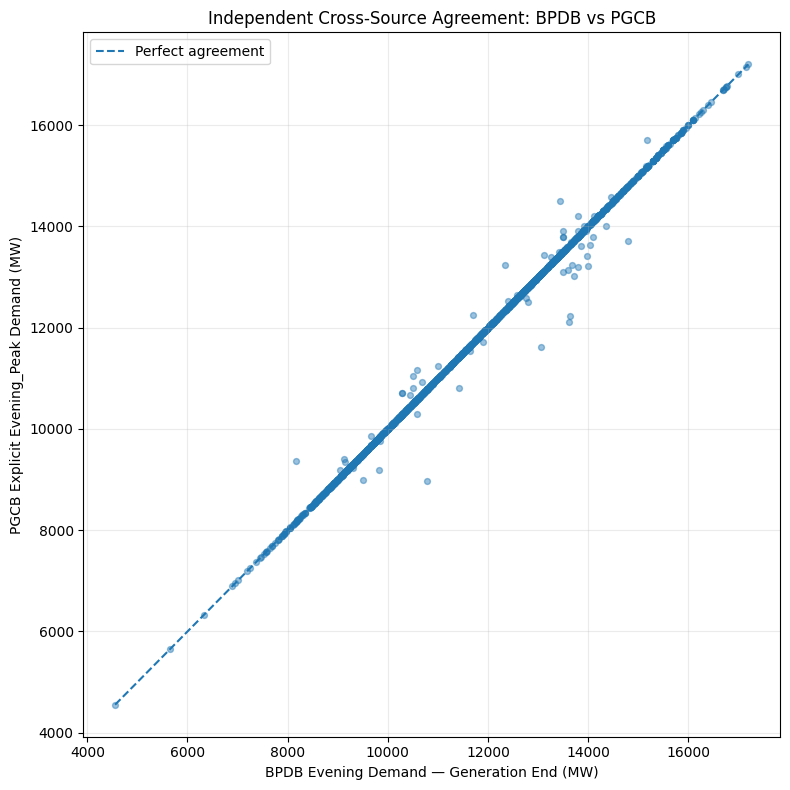

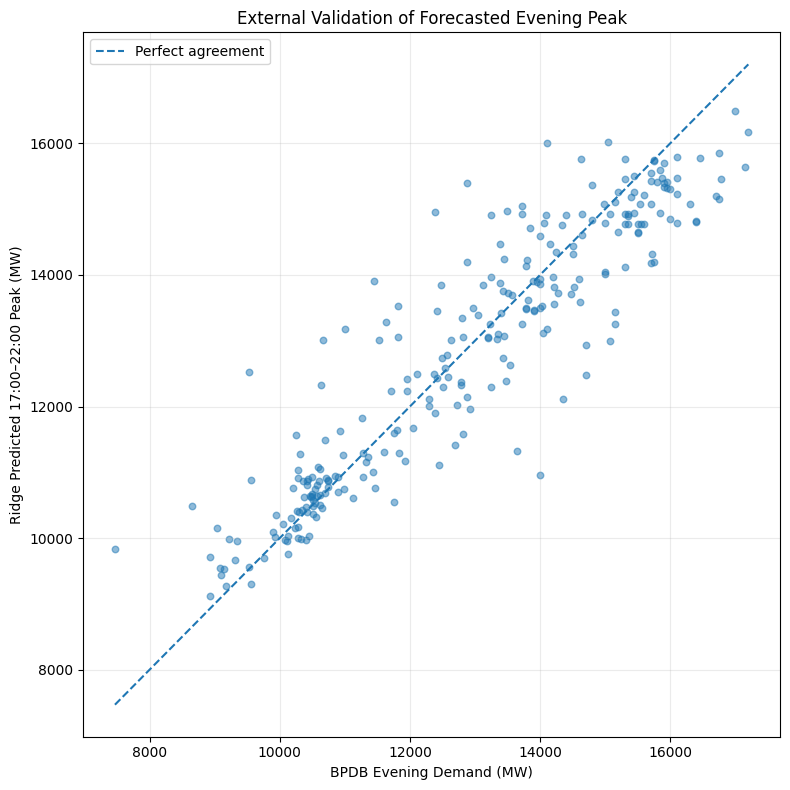

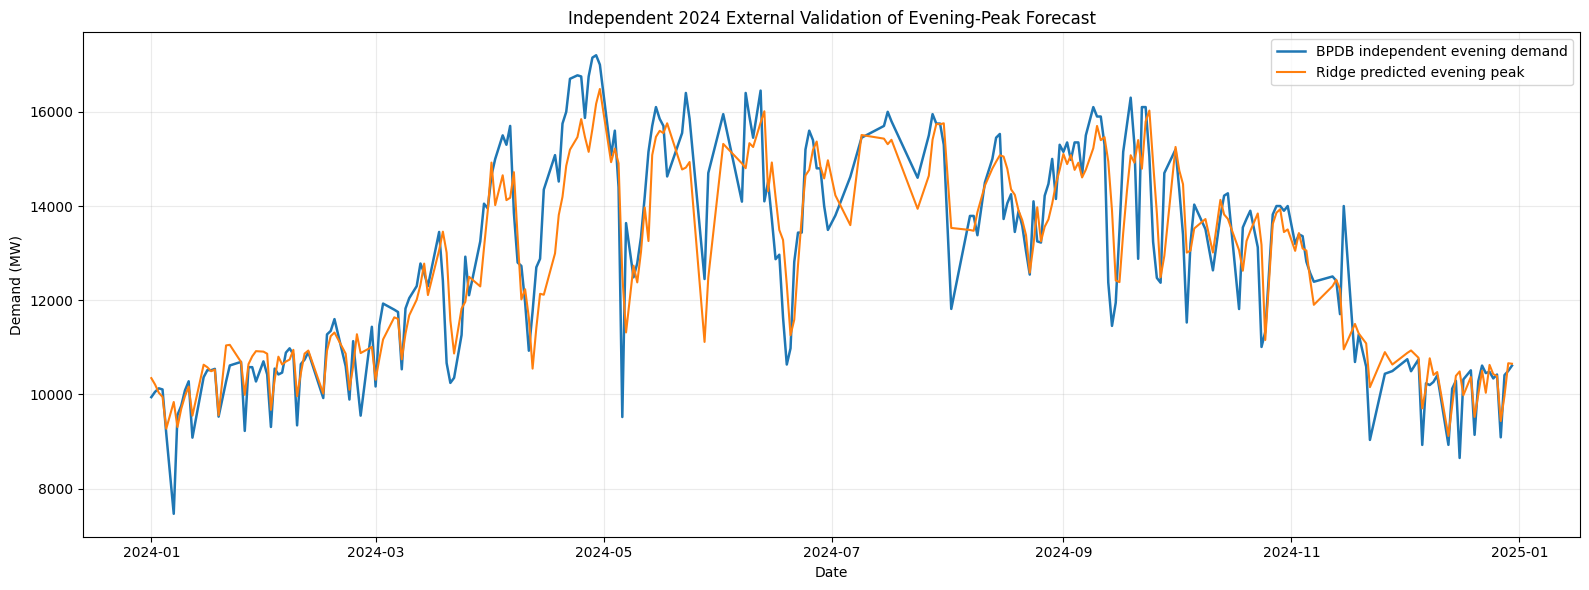

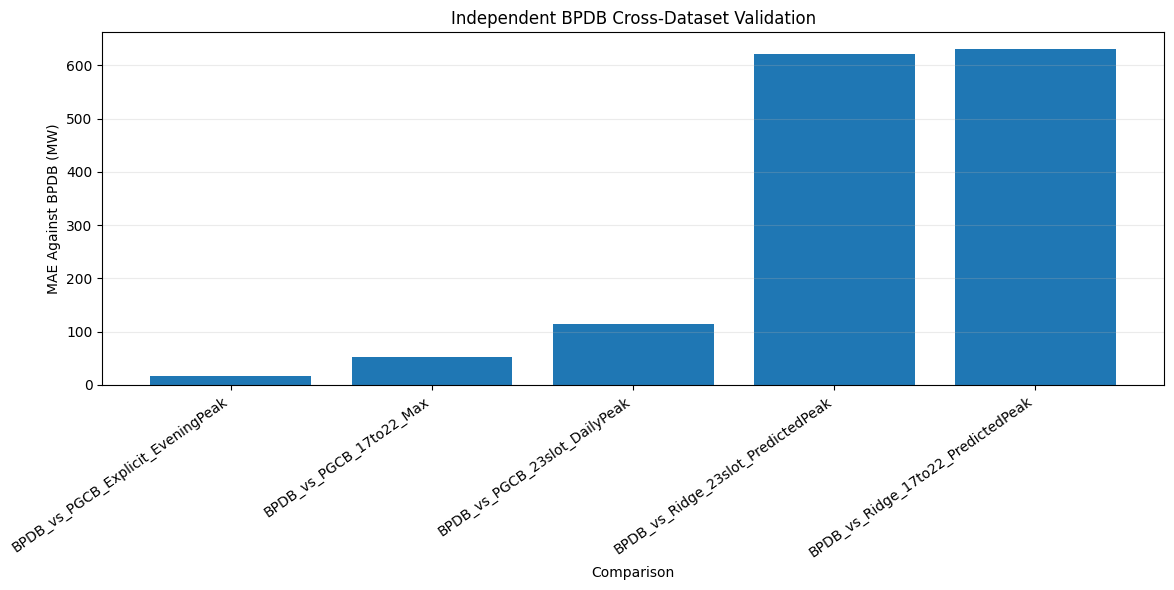

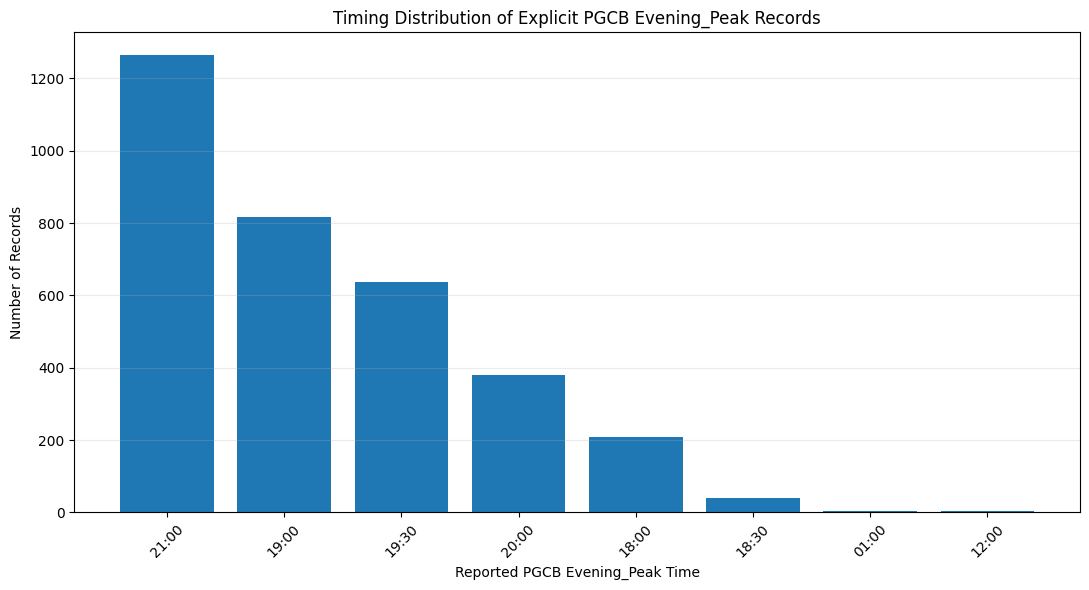


All Step 6 validation checks PASSED.


STEP 6 COMPLETED SUCCESSFULLY

------------------------------------------------------------------------------------------------------------------------
A. BPDB ↔ PGCB SOURCE AGREEMENT
------------------------------------------------------------------------------------------------------------------------
Matched days: 1675
Pearson r: 0.998591
MAE: 15.764 MW
RMSE: 111.972 MW
MAPE: 0.1309 %
Bias: -2.87 MW

------------------------------------------------------------------------------------------------------------------------
B. INDEPENDENT BPDB VALIDATION OF RIDGE EVENING FORECAST
------------------------------------------------------------------------------------------------------------------------
Matched forecast days: 266
Pearson r: 0.920022
MAE: 630.509 MW
RMSE: 872.876 MW
MAPE: 4.928 %
Bias: -57.149 MW

------------------------------------------------------------------------------------------------------------------------
C. 2024 STRICTLY OUT-

In [ ]:
# =====================================================================
# STEP 6 — FULL CORRECTED VERSION
# INDEPENDENT BPDB CROSS-DATASET VALIDATION
#
# FIXES INCLUDED
# --------------
# 1. HOURS variable explicitly defined as 01:00-23:00
# 2. BPDB dates parsed safely using day-first convention
# 3. Hard validation:
#       BPDB start date MUST equal 2019-11-21
# 4. Fixed BPDB Version 2 path
# 5. Defensive column/file checks
#
#
# PURPOSE
# -------
# A. Verify BPDB ↔ PGCB data-source agreement
#
# B. Compare independently recorded BPDB evening demand with:
#
#       - PGCB explicit Evening_Peak
#       - PGCB integer-hour 17:00-22:00 maximum
#       - PGCB full 23-slot daily peak
#
# C. Externally validate the Ridge forecast using:
#
#       - predicted 17:00-22:00 peak
#       - predicted full-profile peak
#
#
# IMPORTANT
# ---------
# BPDB is NEVER used for training, model selection, calibration,
# feature engineering, or test-time tuning.
#
# It is used only as an independent external validation source.
#
# Run this entire block in ONE Google Colab cell.
# =====================================================================


# =====================================================================
# 0. IMPORT LIBRARIES
# =====================================================================

import os
import re
import json
import math
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    250
)

pd.set_option(
    "display.max_rows",
    250
)

pd.set_option(
    "display.width",
    280
)


print("=" * 120)
print("STEP 6: INDEPENDENT BPDB CROSS-DATASET VALIDATION")
print("=" * 120)


# =====================================================================
# 1. MOUNT GOOGLE DRIVE
# =====================================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)


print(
    "\nGoogle Drive mounted successfully."
)


# =====================================================================
# 2. PROJECT DIRECTORIES
# =====================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


STEP3_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml_baselines"
)


STEP5B_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "adaptive_conformal"
)


RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_bpdb_validation"
)


FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "external_bpdb_validation"
)


RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nProject root:"
)

print(
    PROJECT_ROOT
)


# =====================================================================
# 3. FILE PATHS
# =====================================================================

PGCB_AUDIT_FILE = (

    PROCESSED_DIR
    /
    "pgcb_all_rows_quality_flagged.csv"
)


PGCB_FINAL_HOURLY_FILE = (

    PROCESSED_DIR
    /
    "pgcb_final_observed_hourly_target.csv"
)


STEP3_PREDICTION_FILE = (

    STEP3_RESULT_DIR
    /
    "all_test_predictions.csv"
)


ADAPTIVE_INTERVAL_FILE = (

    STEP5B_RESULT_DIR
    /
    "primary_adaptive_90percent_intervals.csv"
)


BPDB_FILE = (

    PROJECT_ROOT
    / "data"
    / "raw"
    / "bpdb"
    / "BPDB_version_2.xlsx"
)


print(
    "\nBPDB Version 2 file:"
)

print(
    BPDB_FILE
)


# =====================================================================
# 4. FORECAST HOURS
#
# PGCB forecasting target:
# 23 observed integer-hour slots = 01:00 through 23:00
# =====================================================================

HOURS = list(
    range(
        1,
        24
    )
)


assert len(HOURS) == 23
assert HOURS[0] == 1
assert HOURS[-1] == 23


print(
    "\nForecast hours:"
)

print(
    HOURS
)


print(
    "Number of forecast slots:",
    len(HOURS)
)


# =====================================================================
# 5. REQUIRED FILE CHECK
# =====================================================================

required_files = [

    PGCB_AUDIT_FILE,

    PGCB_FINAL_HOURLY_FILE,

    STEP3_PREDICTION_FILE,

    BPDB_FILE
]


print("\n" + "=" * 120)

print(
    "REQUIRED FILE CHECK"
)

print("=" * 120)


for required_file in required_files:

    exists = (
        required_file.exists()
    )


    print(
        required_file,
        "->",
        exists
    )


    if not exists:

        raise FileNotFoundError(
            f"""
Required file not found:

{required_file}
"""
        )


print(
    "\nAll required files found."
)


# =====================================================================
# 6. LOAD BPDB VERSION 2
# =====================================================================

bpdb = pd.read_excel(
    BPDB_FILE
)


print("\n" + "=" * 120)

print(
    "BPDB VERSION 2 LOADED"
)

print("=" * 120)


print(
    "Rows:",
    len(bpdb)
)


print(
    "Columns:",
    len(bpdb.columns)
)


print(
    "\nBPDB columns:"
)


for index, column in enumerate(
    bpdb.columns
):

    print(
        f"{index:02d}: {column}"
    )


# =====================================================================
# 7. COLUMN-NAME NORMALIZATION HELPER
# =====================================================================

def normalize_column_name(
    value
):

    text = str(
        value
    ).strip().lower()


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text


# =====================================================================
# 8. IDENTIFY BPDB DATE COLUMN
# =====================================================================

date_candidates = [

    column

    for column in bpdb.columns

    if normalize_column_name(
        column
    )
    in
    [
        "date",
        "dates"
    ]
]


if len(
    date_candidates
) == 0:

    date_candidates = [

        column

        for column in bpdb.columns

        if "date"
        in
        normalize_column_name(
            column
        )
    ]


if len(
    date_candidates
) == 0:

    raise ValueError(
        """
Could not identify BPDB date column.
"""
    )


BPDB_DATE_COLUMN = (
    date_candidates[0]
)


print(
    "\nSelected BPDB date column:"
)

print(
    BPDB_DATE_COLUMN
)


# =====================================================================
# 9. CORRECT BPDB DATE PARSING
#
# CRITICAL FIX
#
# BPDB Version 2 uses day-first dates.
#
# Example:
#
#       21/11/2019
#
# means:
#
#       21 November 2019
#
# NOT an MM/DD/YYYY interpretation.
# =====================================================================

raw_bpdb_dates = (

    bpdb[
        BPDB_DATE_COLUMN
    ]
    .copy()
)


print(
    "\nOriginal BPDB Date dtype:",
    raw_bpdb_dates.dtype
)


print(
    "\nFirst 10 raw date values:"
)


display(
    raw_bpdb_dates.head(
        10
    )
)


# ---------------------------------------------------------------------
# Case A:
# Excel reader already returned genuine datetime objects.
#
# In this case no ambiguous string interpretation is required.
# ---------------------------------------------------------------------

if pd.api.types.is_datetime64_any_dtype(
    raw_bpdb_dates
):

    parsed_bpdb_dates = pd.to_datetime(

        raw_bpdb_dates,

        errors="coerce"
    )


# ---------------------------------------------------------------------
# Case B:
# Dates are strings / object type.
#
# Explicitly parse as day-first.
# ---------------------------------------------------------------------

else:

    parsed_bpdb_dates = pd.to_datetime(

        raw_bpdb_dates,

        errors="coerce",

        dayfirst=True
    )


bpdb[
    BPDB_DATE_COLUMN
] = (
    parsed_bpdb_dates
)


# Remove invalid dates only.

bpdb = (

    bpdb
    .dropna(
        subset=[
            BPDB_DATE_COLUMN
        ]
    )

    .sort_values(
        BPDB_DATE_COLUMN
    )

    .reset_index(
        drop=True
    )
)


bpdb[
    "date"
] = (

    bpdb[
        BPDB_DATE_COLUMN
    ]
    .dt.normalize()
)


print("\n" + "=" * 120)

print(
    "CORRECTED BPDB DATE PARSING"
)

print("=" * 120)


print(
    "Start:",
    bpdb[
        "date"
    ].min()
)


print(
    "End:",
    bpdb[
        "date"
    ].max()
)


print(
    "Rows:",
    len(
        bpdb
    )
)


print(
    "Unique dates:",
    bpdb[
        "date"
    ].nunique()
)


# =====================================================================
# 10. HARD BPDB DATE SAFETY CHECK
#
# Our previously audited Version 2 begins:
#
#       2019-11-21
#
# and ends:
#
#       2024-12-30
#
# If this fails, STOP.
# =====================================================================

EXPECTED_START_DATE = pd.Timestamp(
    "2019-11-21"
)


EXPECTED_END_DATE = pd.Timestamp(
    "2024-12-30"
)


actual_start_date = (

    bpdb[
        "date"
    ].min()
)


actual_end_date = (

    bpdb[
        "date"
    ].max()
)


if (
    actual_start_date
    !=
    EXPECTED_START_DATE
):

    raise RuntimeError(
        f"""
============================================================

BPDB DATE PARSING CHECK FAILED

Expected first date:
{EXPECTED_START_DATE.date()}

Actual first date:
{actual_start_date.date()}

DO NOT CONTINUE STEP 6.

Send the first 10 raw BPDB date values printed above
to ChatGPT.

============================================================
"""
    )


if (
    actual_end_date
    !=
    EXPECTED_END_DATE
):

    raise RuntimeError(
        f"""
============================================================

BPDB END-DATE CHECK FAILED

Expected final date:
{EXPECTED_END_DATE.date()}

Actual final date:
{actual_end_date.date()}

DO NOT CONTINUE STEP 6.

============================================================
"""
    )


print(
    "\nBPDB DATE VALIDATION PASSED."
)


# =====================================================================
# 11. CHECK BPDB DUPLICATE DATES
# =====================================================================

duplicate_bpdb_dates = int(

    bpdb[
        "date"
    ]
    .duplicated()
    .sum()
)


print(
    "\nDuplicate BPDB dates:",
    duplicate_bpdb_dates
)


if (
    duplicate_bpdb_dates
    >
    0
):

    print(
        "\nWARNING:"
    )

    print(
        "Duplicate BPDB dates detected."
    )


# =====================================================================
# 12. IDENTIFY BPDB NATIONAL EVENING-DEMAND COLUMNS
# =====================================================================

generation_end_candidates = []

substation_end_candidates = []


for column in bpdb.columns:

    normalized = normalize_column_name(
        column
    )


    if (

        "demand"
        in
        normalized

        and

        (
            "eve"
            in
            normalized

            or

            "evening"
            in
            normalized
        )

        and

        "generation"
        in
        normalized

    ):

        generation_end_candidates.append(
            column
        )


    if (

        "demand"
        in
        normalized

        and

        (
            "eve"
            in
            normalized

            or

            "evening"
            in
            normalized
        )

        and

        "sub"
        in
        normalized

    ):

        substation_end_candidates.append(
            column
        )


print(
    "\nGeneration-end evening-demand candidates:"
)

print(
    generation_end_candidates
)


print(
    "\nSubstation-end evening-demand candidates:"
)

print(
    substation_end_candidates
)


if len(
    generation_end_candidates
) == 0:

    raise ValueError(
        """
BPDB generation-end evening demand column was not found.
"""
    )


BPDB_EVENING_GENERATION_COLUMN = (
    generation_end_candidates[0]
)


BPDB_EVENING_SUBSTATION_COLUMN = (

    substation_end_candidates[0]

    if len(
        substation_end_candidates
    )
    >
    0

    else None
)


print(
    "\nSelected BPDB generation-end column:"
)

print(
    BPDB_EVENING_GENERATION_COLUMN
)


if (
    BPDB_EVENING_SUBSTATION_COLUMN
    is not None
):

    print(
        "\nSelected BPDB substation-end column:"
    )

    print(
        BPDB_EVENING_SUBSTATION_COLUMN
    )


# =====================================================================
# 13. NUMERIC BPDB DEMAND VALUES
# =====================================================================

bpdb[
    "bpdb_evening_generation_mw"
] = pd.to_numeric(

    bpdb[
        BPDB_EVENING_GENERATION_COLUMN
    ],

    errors="coerce"
)


if (
    BPDB_EVENING_SUBSTATION_COLUMN
    is not None
):

    bpdb[
        "bpdb_evening_substation_mw"
    ] = pd.to_numeric(

        bpdb[
            BPDB_EVENING_SUBSTATION_COLUMN
        ],

        errors="coerce"
    )


# =====================================================================
# 14. BPDB PLAUSIBILITY FILTER
#
# No interpolation.
# No smoothing.
# No replacement.
#
# Only impossible/non-national-scale entries removed.
# =====================================================================

bpdb.loc[

    ~bpdb[
        "bpdb_evening_generation_mw"
    ]
    .between(
        1000,
        30000
    ),

    "bpdb_evening_generation_mw"

] = np.nan


if (
    "bpdb_evening_substation_mw"
    in
    bpdb.columns
):

    bpdb.loc[

        ~bpdb[
            "bpdb_evening_substation_mw"
        ]
        .between(
            1000,
            30000
        ),

        "bpdb_evening_substation_mw"

    ] = np.nan


print(
    "\nValid BPDB generation-end evening values:",
    int(
        bpdb[
            "bpdb_evening_generation_mw"
        ]
        .notna()
        .sum()
    )
)


if (
    "bpdb_evening_substation_mw"
    in
    bpdb.columns
):

    print(
        "Valid BPDB substation-end evening values:",
        int(
            bpdb[
                "bpdb_evening_substation_mw"
            ]
            .notna()
            .sum()
        )
    )


# =====================================================================
# 15. LOAD PGCB QUALITY-AUDITED ALL-ROWS DATA
# =====================================================================

pgcb_all = pd.read_csv(
    PGCB_AUDIT_FILE,
    low_memory=False
)


if (
    "datetime"
    not in
    pgcb_all.columns
):

    raise ValueError(
        """
PGCB audit file does not contain 'datetime'.
"""
    )


pgcb_all[
    "datetime"
] = pd.to_datetime(

    pgcb_all[
        "datetime"
    ],

    errors="coerce"
)


pgcb_all = (

    pgcb_all
    .dropna(
        subset=[
            "datetime"
        ]
    )

    .sort_values(
        "datetime"
    )

    .reset_index(
        drop=True
    )
)


pgcb_all[
    "date"
] = (

    pgcb_all[
        "datetime"
    ]
    .dt.normalize()
)


print(
    "\nPGCB audit rows loaded:",
    len(
        pgcb_all
    )
)


# =====================================================================
# 16. IDENTIFY PGCB DEMAND COLUMN
# =====================================================================

if (
    "demand_original"
    in
    pgcb_all.columns
):

    PGCB_DEMAND_COLUMN = (
        "demand_original"
    )


elif (
    "demand_mw"
    in
    pgcb_all.columns
):

    PGCB_DEMAND_COLUMN = (
        "demand_mw"
    )


elif (
    "demand_final"
    in
    pgcb_all.columns
):

    PGCB_DEMAND_COLUMN = (
        "demand_final"
    )


else:

    raise ValueError(
        """
No PGCB demand column could be identified.
"""
    )


pgcb_all[
    PGCB_DEMAND_COLUMN
] = pd.to_numeric(

    pgcb_all[
        PGCB_DEMAND_COLUMN
    ],

    errors="coerce"
)


print(
    "PGCB demand column selected:",
    PGCB_DEMAND_COLUMN
)


# =====================================================================
# 17. SAFE BOOLEAN FUNCTION
# =====================================================================

def safe_bool(
    series
):

    if pd.api.types.is_bool_dtype(
        series
    ):

        return series.fillna(
            False
        )


    normalized = (

        series
        .astype(str)
        .str.strip()
        .str.lower()
    )


    mapped = normalized.map(
        {

            "true":
                True,

            "false":
                False,

            "1":
                True,

            "0":
                False,

            "yes":
                True,

            "no":
                False
        }
    )


    return (

        mapped
        .fillna(
            False
        )

        .astype(bool)
    )


if (
    "demand_corrupt"
    in
    pgcb_all.columns
):

    pgcb_all[
        "demand_corrupt"
    ] = safe_bool(

        pgcb_all[
            "demand_corrupt"
        ]
    )


else:

    pgcb_all[
        "demand_corrupt"
    ] = False


    print(
        "\nWARNING: demand_corrupt column not found."
    )


# =====================================================================
# 18. CLEAN REMARKS
# =====================================================================

if (
    "remarks"
    not in
    pgcb_all.columns
):

    raise ValueError(
        """
PGCB remarks column is missing.
"""
    )


pgcb_all[
    "remarks_clean"
] = (

    pgcb_all[
        "remarks"
    ]

    .fillna(
        ""
    )

    .astype(str)

    .str.strip()

    .str.lower()
)


# =====================================================================
# 19. EXPLICIT PGCB Evening_Peak EXTRACTION
# =====================================================================

explicit_evening = (

    pgcb_all.loc[

        pgcb_all[
            "remarks_clean"
        ]
        .eq(
            "evening_peak"
        )

        &

        (
            ~pgcb_all[
                "demand_corrupt"
            ]
        )

        &

        pgcb_all[
            PGCB_DEMAND_COLUMN
        ]
        .between(
            1000,
            30000
        )
    ]

    .copy()
)


print("\n" + "=" * 120)

print(
    "EXPLICIT PGCB EVENING_PEAK SERIES"
)

print("=" * 120)


print(
    "Rows:",
    len(
        explicit_evening
    )
)


print(
    "Period:",
    explicit_evening[
        "datetime"
    ].min(),
    "to",
    explicit_evening[
        "datetime"
    ].max()
)


# =====================================================================
# 20. Evening_Peak TIMESTAMP DISTRIBUTION
# =====================================================================

explicit_evening[
    "time_string"
] = (

    explicit_evening[
        "datetime"
    ]
    .dt.strftime(
        "%H:%M"
    )
)


evening_time_distribution = (

    explicit_evening[
        "time_string"
    ]

    .value_counts()

    .rename_axis(
        "time"
    )

    .reset_index(
        name="count"
    )
)


print(
    "\nExplicit Evening_Peak timestamp distribution:"
)


display(
    evening_time_distribution.head(
        30
    )
)


# =====================================================================
# 21. ONE EXPLICIT EVENING_PEAK VALUE PER DATE
# =====================================================================

pgcb_evening_daily = (

    explicit_evening

    .groupby(
        "date",
        as_index=False
    )

    .agg(

        pgcb_evening_peak_mw=(
            PGCB_DEMAND_COLUMN,
            "max"
        ),

        pgcb_evening_peak_records=(
            PGCB_DEMAND_COLUMN,
            "size"
        )
    )
)


print(
    "\nUnique PGCB Evening_Peak dates:",
    len(
        pgcb_evening_daily
    )
)


# =====================================================================
# 22. LOAD FINAL CLEAN PGCB HOURLY TARGET
# =====================================================================

pgcb_hourly = pd.read_csv(
    PGCB_FINAL_HOURLY_FILE,
    low_memory=False
)


if (
    "datetime"
    not in
    pgcb_hourly.columns
):

    raise ValueError(
        """
Clean PGCB target file does not contain datetime.
"""
    )


pgcb_hourly[
    "datetime"
] = pd.to_datetime(

    pgcb_hourly[
        "datetime"
    ],

    errors="coerce"
)


pgcb_hourly = (

    pgcb_hourly
    .dropna(
        subset=[
            "datetime"
        ]
    )

    .sort_values(
        "datetime"
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 23. CLEAN PGCB HOURLY DEMAND COLUMN
# =====================================================================

if (
    "demand_final"
    in
    pgcb_hourly.columns
):

    HOURLY_DEMAND_COLUMN = (
        "demand_final"
    )


elif (
    "demand_mw"
    in
    pgcb_hourly.columns
):

    HOURLY_DEMAND_COLUMN = (
        "demand_mw"
    )


elif (
    "demand_original"
    in
    pgcb_hourly.columns
):

    HOURLY_DEMAND_COLUMN = (
        "demand_original"
    )


else:

    raise ValueError(
        """
Clean hourly PGCB demand column could not be found.
"""
    )


pgcb_hourly[
    HOURLY_DEMAND_COLUMN
] = pd.to_numeric(

    pgcb_hourly[
        HOURLY_DEMAND_COLUMN
    ],

    errors="coerce"
)


pgcb_hourly[
    "date"
] = (

    pgcb_hourly[
        "datetime"
    ]
    .dt.normalize()
)


pgcb_hourly[
    "hour"
] = (

    pgcb_hourly[
        "datetime"
    ]
    .dt.hour
)


print(
    "\nClean PGCB hourly rows:",
    len(
        pgcb_hourly
    )
)


print(
    "Hourly target column:",
    HOURLY_DEMAND_COLUMN
)


# =====================================================================
# 24. ACTUAL PGCB 23-SLOT DAILY PEAK
# =====================================================================

actual_daily_profile_peak = (

    pgcb_hourly.loc[

        pgcb_hourly[
            "hour"
        ]
        .between(
            1,
            23
        )

        &

        pgcb_hourly[
            HOURLY_DEMAND_COLUMN
        ]
        .notna()
    ]

    .groupby(
        "date",
        as_index=False
    )

    .agg(

        pgcb_23slot_peak_mw=(
            HOURLY_DEMAND_COLUMN,
            "max"
        ),

        available_slots=(
            "hour",
            "nunique"
        )
    )
)


# =====================================================================
# 25. ACTUAL INTEGER-HOUR EVENING MAXIMUM
#
# 17:00 through 22:00
# =====================================================================

actual_evening_window_peak = (

    pgcb_hourly.loc[

        pgcb_hourly[
            "hour"
        ]
        .between(
            17,
            22
        )

        &

        pgcb_hourly[
            HOURLY_DEMAND_COLUMN
        ]
        .notna()
    ]

    .groupby(
        "date",
        as_index=False
    )

    .agg(

        pgcb_evening_window_max_mw=(
            HOURLY_DEMAND_COLUMN,
            "max"
        ),

        evening_slots_available=(
            "hour",
            "nunique"
        )
    )
)


# =====================================================================
# 26. LOAD STEP 3 RIDGE TEST PREDICTIONS
# =====================================================================

prediction_df = pd.read_csv(
    STEP3_PREDICTION_FILE,
    low_memory=False
)


if (
    "target_date"
    not in
    prediction_df.columns
):

    raise ValueError(
        """
Step 3 all_test_predictions.csv does not contain target_date.
"""
    )


prediction_df[
    "target_date"
] = pd.to_datetime(

    prediction_df[
        "target_date"
    ],

    errors="coerce"
)


prediction_df = (

    prediction_df
    .dropna(
        subset=[
            "target_date"
        ]
    )

    .sort_values(
        "target_date"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nStep 3 prediction rows:",
    len(
        prediction_df
    )
)


# =====================================================================
# 27. CHECK ALL 23 RIDGE PREDICTION COLUMNS
# =====================================================================

ridge_prediction_columns = [

    f"ridge_pred_h{hour:02d}"

    for hour in HOURS
]


missing_ridge_columns = [

    column

    for column in ridge_prediction_columns

    if column
    not in
    prediction_df.columns
]


if len(
    missing_ridge_columns
) > 0:

    print(
        "\nAvailable Ridge-related columns:"
    )


    print(
        [
            column

            for column in prediction_df.columns

            if "ridge"
            in
            column.lower()
        ]
    )


    raise ValueError(
        f"""
Missing expected Ridge columns:

{missing_ridge_columns}
"""
    )


print(
    "All 23 Ridge prediction columns found."
)


# =====================================================================
# 28. RIDGE FULL-PROFILE PEAK FORECAST
# =====================================================================

prediction_df[
    "ridge_profile_peak_mw"
] = (

    prediction_df[
        ridge_prediction_columns
    ]

    .max(
        axis=1
    )
)


ridge_profile_idx = (

    prediction_df[
        ridge_prediction_columns
    ]

    .idxmax(
        axis=1
    )
)


prediction_df[
    "ridge_profile_peak_hour"
] = pd.to_numeric(

    ridge_profile_idx
    .str.extract(
        r"h(\d+)"
    )[0],

    errors="coerce"
)


# =====================================================================
# 29. RIDGE 17:00-22:00 EVENING PEAK FORECAST
# =====================================================================

ridge_evening_columns = [

    f"ridge_pred_h{hour:02d}"

    for hour in range(
        17,
        23
    )
]


prediction_df[
    "ridge_evening_peak_mw"
] = (

    prediction_df[
        ridge_evening_columns
    ]

    .max(
        axis=1
    )
)


ridge_evening_idx = (

    prediction_df[
        ridge_evening_columns
    ]

    .idxmax(
        axis=1
    )
)


prediction_df[
    "ridge_evening_peak_hour"
] = pd.to_numeric(

    ridge_evening_idx
    .str.extract(
        r"h(\d+)"
    )[0],

    errors="coerce"
)


prediction_df[
    "date"
] = (

    prediction_df[
        "target_date"
    ]
    .dt.normalize()
)


print(
    "\nRidge prediction period:",
    prediction_df[
        "date"
    ].min(),
    "to",
    prediction_df[
        "date"
    ].max()
)


# =====================================================================
# 30. BUILD EXTERNAL VALIDATION MASTER TABLE
# =====================================================================

bpdb_columns_for_merge = [

    "date",

    "bpdb_evening_generation_mw"
]


if (
    "bpdb_evening_substation_mw"
    in
    bpdb.columns
):

    bpdb_columns_for_merge.append(
        "bpdb_evening_substation_mw"
    )


external = (

    bpdb[
        bpdb_columns_for_merge
    ]

    .copy()

    .merge(

        pgcb_evening_daily,

        on="date",

        how="left"
    )

    .merge(

        actual_daily_profile_peak,

        on="date",

        how="left"
    )

    .merge(

        actual_evening_window_peak,

        on="date",

        how="left"
    )

    .merge(

        prediction_df[
            [
                "date",

                "ridge_profile_peak_mw",

                "ridge_profile_peak_hour",

                "ridge_evening_peak_mw",

                "ridge_evening_peak_hour"
            ]
        ],

        on="date",

        how="left"
    )
)


external[
    "year"
] = (

    external[
        "date"
    ]
    .dt.year
)


print("\n" + "=" * 120)

print(
    "EXTERNAL VALIDATION MASTER TABLE"
)

print("=" * 120)


print(
    "BPDB dates:",
    len(
        external
    )
)


source_match_count = (

    external[
        [
            "bpdb_evening_generation_mw",

            "pgcb_evening_peak_mw"
        ]
    ]

    .dropna()

    .shape[0]
)


ridge_match_count = (

    external[
        [
            "bpdb_evening_generation_mw",

            "ridge_evening_peak_mw"
        ]
    ]

    .dropna()

    .shape[0]
)


print(
    "BPDB + explicit PGCB Evening_Peak:",
    source_match_count
)


print(
    "BPDB + Ridge 17-22 predicted peak:",
    ridge_match_count
)


# =====================================================================
# 31. METRIC FUNCTIONS
# =====================================================================

def mae(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.mean(

            np.abs(

                actual

                -

                predicted
            )
        )
    )


def rmse(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.sqrt(

            np.mean(

                (
                    actual

                    -

                    predicted
                )

                ** 2
            )
        )
    )


def mape(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    denominator = np.maximum(

        np.abs(
            actual
        ),

        1e-6
    )


    return float(

        100

        *

        np.mean(

            np.abs(

                (
                    actual

                    -

                    predicted
                )

                /

                denominator
            )
        )
    )


def smape(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    denominator = (

        np.abs(
            actual
        )

        +

        np.abs(
            predicted
        )
    )


    valid = (
        denominator > 0
    )


    return float(

        100

        *

        np.mean(

            2

            *

            np.abs(

                actual[
                    valid
                ]

                -

                predicted[
                    valid
                ]
            )

            /

            denominator[
                valid
            ]
        )
    )


def correlation(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    if len(
        actual
    ) < 2:

        return np.nan


    if (

        np.std(
            actual
        )
        ==
        0

        or

        np.std(
            predicted
        )
        ==
        0
    ):

        return np.nan


    return float(

        np.corrcoef(

            actual,

            predicted
        )[
            0,
            1
        ]
    )


def bias(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.mean(

            predicted

            -

            actual
        )
    )


# =====================================================================
# 32. GENERIC EXTERNAL COMPARISON
# =====================================================================

def compare_series(
    dataframe,
    actual_column,
    comparison_column,
    comparison_name
):

    required_columns = [

        "date",

        actual_column,

        comparison_column
    ]


    missing_columns = [

        column

        for column in required_columns

        if column
        not in
        dataframe.columns
    ]


    if missing_columns:

        raise ValueError(
            f"""
Missing columns for comparison:

{comparison_name}

{missing_columns}
"""
        )


    temp = (

        dataframe[
            required_columns
        ]

        .dropna()

        .copy()
    )


    if len(
        temp
    ) == 0:

        return {

            "comparison":
                comparison_name,

            "n":
                0,

            "Pearson_r":
                np.nan,

            "MAE_MW":
                np.nan,

            "RMSE_MW":
                np.nan,

            "MAPE_percent":
                np.nan,

            "sMAPE_percent":
                np.nan,

            "Bias_MW":
                np.nan
        }


    actual = (

        temp[
            actual_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    predicted = (

        temp[
            comparison_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    return {

        "comparison":
            comparison_name,

        "n":
            int(
                len(
                    temp
                )
            ),

        "Pearson_r":
            correlation(
                actual,
                predicted
            ),

        "MAE_MW":
            mae(
                actual,
                predicted
            ),

        "RMSE_MW":
            rmse(
                actual,
                predicted
            ),

        "MAPE_percent":
            mape(
                actual,
                predicted
            ),

        "sMAPE_percent":
            smape(
                actual,
                predicted
            ),

        "Bias_MW":
            bias(
                actual,
                predicted
            )
    }


# =====================================================================
# 33. PRIMARY BPDB GENERATION-END COMPARISONS
# =====================================================================

comparison_rows = []


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_evening_peak_mw",

        comparison_name=
            "BPDB_vs_PGCB_Explicit_EveningPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_evening_window_max_mw",

        comparison_name=
            "BPDB_vs_PGCB_17to22_Max"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "pgcb_23slot_peak_mw",

        comparison_name=
            "BPDB_vs_PGCB_23slot_DailyPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "ridge_evening_peak_mw",

        comparison_name=
            "BPDB_vs_Ridge_17to22_PredictedPeak"
    )
)


comparison_rows.append(

    compare_series(

        external,

        actual_column=
            "bpdb_evening_generation_mw",

        comparison_column=
            "ridge_profile_peak_mw",

        comparison_name=
            "BPDB_vs_Ridge_23slot_PredictedPeak"
    )
)


comparison_results = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 120)

print(
    "PRIMARY BPDB EXTERNAL VALIDATION RESULTS"
)

print("=" * 120)


display(
    comparison_results.round(
        4
    )
)


# =====================================================================
# 34. OPTIONAL BPDB SUBSTATION-END COMPARISONS
# =====================================================================

substation_results = pd.DataFrame()


if (
    "bpdb_evening_substation_mw"
    in
    external.columns
):

    substation_rows = []


    substation_comparisons = [

        (
            "pgcb_evening_peak_mw",

            "BPDB_Substation_vs_PGCB_Explicit_EveningPeak"
        ),

        (
            "pgcb_evening_window_max_mw",

            "BPDB_Substation_vs_PGCB_17to22_Max"
        ),

        (
            "ridge_evening_peak_mw",

            "BPDB_Substation_vs_Ridge_17to22_PredictedPeak"
        ),

        (
            "ridge_profile_peak_mw",

            "BPDB_Substation_vs_Ridge_23slot_PredictedPeak"
        )
    ]


    for (
        comparison_column,
        comparison_name
    ) in substation_comparisons:

        substation_rows.append(

            compare_series(

                external,

                actual_column=
                    "bpdb_evening_substation_mw",

                comparison_column=
                    comparison_column,

                comparison_name=
                    comparison_name
            )
        )


    substation_results = pd.DataFrame(
        substation_rows
    )


    print("\n" + "=" * 120)

    print(
        "OPTIONAL BPDB SUBSTATION-END RESULTS"
    )

    print("=" * 120)


    display(
        substation_results.round(
            4
        )
    )


# =====================================================================
# 35. YEAR-WISE RIDGE EXTERNAL PERFORMANCE
# =====================================================================

yearly_rows = []


for year in sorted(

    external[
        "year"
    ]
    .dropna()
    .unique()
):

    year = int(
        year
    )


    temp = (

        external.loc[

            external[
                "year"
            ]
            ==
            year,

            [
                "date",

                "bpdb_evening_generation_mw",

                "ridge_evening_peak_mw"
            ]
        ]

        .dropna()
    )


    if len(
        temp
    ) < 10:

        continue


    actual = (

        temp[
            "bpdb_evening_generation_mw"
        ]
    )


    predicted = (

        temp[
            "ridge_evening_peak_mw"
        ]
    )


    yearly_rows.append(
        {

            "year":
                year,

            "n":
                int(
                    len(
                        temp
                    )
                ),

            "Pearson_r":
                correlation(
                    actual,
                    predicted
                ),

            "MAE_MW":
                mae(
                    actual,
                    predicted
                ),

            "RMSE_MW":
                rmse(
                    actual,
                    predicted
                ),

            "MAPE_percent":
                mape(
                    actual,
                    predicted
                ),

            "sMAPE_percent":
                smape(
                    actual,
                    predicted
                ),

            "Bias_MW":
                bias(
                    actual,
                    predicted
                )
        }
    )


yearly_external_forecast = pd.DataFrame(
    yearly_rows
)


print("\n" + "=" * 120)

print(
    "YEAR-WISE RIDGE EXTERNAL PERFORMANCE"
)

print("=" * 120)


if len(
    yearly_external_forecast
) > 0:

    display(
        yearly_external_forecast.round(
            4
        )
    )


else:

    print(
        "No year contained at least 10 matched forecast days."
    )


# =====================================================================
# 36. YEAR-WISE BPDB ↔ PGCB SOURCE AGREEMENT
# =====================================================================

source_yearly_rows = []


for year in sorted(

    external[
        "year"
    ]
    .dropna()
    .unique()
):

    year = int(
        year
    )


    temp = (

        external.loc[

            external[
                "year"
            ]
            ==
            year,

            [
                "date",

                "bpdb_evening_generation_mw",

                "pgcb_evening_peak_mw"
            ]
        ]

        .dropna()
    )


    if len(
        temp
    ) < 10:

        continue


    actual = (

        temp[
            "bpdb_evening_generation_mw"
        ]
    )


    comparison = (

        temp[
            "pgcb_evening_peak_mw"
        ]
    )


    source_yearly_rows.append(
        {

            "year":
                year,

            "n":
                int(
                    len(
                        temp
                    )
                ),

            "Pearson_r":
                correlation(
                    actual,
                    comparison
                ),

            "MAE_MW":
                mae(
                    actual,
                    comparison
                ),

            "RMSE_MW":
                rmse(
                    actual,
                    comparison
                ),

            "MAPE_percent":
                mape(
                    actual,
                    comparison
                ),

            "Bias_MW":
                bias(
                    actual,
                    comparison
                )
        }
    )


source_yearly_results = pd.DataFrame(
    source_yearly_rows
)


print("\n" + "=" * 120)

print(
    "YEAR-WISE BPDB ↔ PGCB SOURCE AGREEMENT"
)

print("=" * 120)


display(
    source_yearly_results.round(
        4
    )
)


# =====================================================================
# 37. STRICT 2024 EXTERNAL FORECAST VALIDATION
#
# BPDB Version 2 ends on 2024-12-30.
#
# Our locked final test starts in 2024.
#
# Therefore 2024 is the independently overlapping portion.
# =====================================================================

external_2024 = (

    external.loc[
        external[
            "year"
        ]
        ==
        2024
    ]

    .copy()
)


external_2024_forecast = (

    external_2024[
        [
            "date",

            "bpdb_evening_generation_mw",

            "ridge_evening_peak_mw",

            "ridge_profile_peak_mw"
        ]
    ]

    .dropna(
        subset=[
            "bpdb_evening_generation_mw",

            "ridge_evening_peak_mw"
        ]
    )
)


result_2024_evening = None


print("\n" + "=" * 120)

print(
    "2024 STRICTLY OUT-OF-SAMPLE BPDB VALIDATION"
)

print("=" * 120)


if len(
    external_2024_forecast
) > 0:

    result_2024_evening = (

        compare_series(

            external_2024_forecast,

            actual_column=
                "bpdb_evening_generation_mw",

            comparison_column=
                "ridge_evening_peak_mw",

            comparison_name=
                "2024_BPDB_vs_Ridge_17to22_PredictedPeak"
        )
    )


    print(
        "Matched days:",
        result_2024_evening[
            "n"
        ]
    )


    print(
        "Pearson r:",
        round(
            result_2024_evening[
                "Pearson_r"
            ],
            6
        )
    )


    print(
        "MAE:",
        round(
            result_2024_evening[
                "MAE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        "RMSE:",
        round(
            result_2024_evening[
                "RMSE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        "MAPE:",
        round(
            result_2024_evening[
                "MAPE_percent"
            ],
            3
        ),
        "%"
    )


    print(
        "sMAPE:",
        round(
            result_2024_evening[
                "sMAPE_percent"
            ],
            3
        ),
        "%"
    )


    print(
        "Bias:",
        round(
            result_2024_evening[
                "Bias_MW"
            ],
            3
        ),
        "MW"
    )


else:

    print(
        "No matched 2024 BPDB/Ridge observations."
    )


# =====================================================================
# 38. SAVE OUTPUT TABLES
# =====================================================================

MASTER_FILE = (

    RESULT_DIR
    /
    "bpdb_pgcb_external_validation_master.csv"
)


COMPARISON_FILE = (

    RESULT_DIR
    /
    "external_validation_comparison.csv"
)


SUBSTATION_FILE = (

    RESULT_DIR
    /
    "external_validation_substation_comparison.csv"
)


YEARLY_FORECAST_FILE = (

    RESULT_DIR
    /
    "external_forecast_by_year.csv"
)


YEARLY_SOURCE_FILE = (

    RESULT_DIR
    /
    "pgcb_bpdb_source_agreement_by_year.csv"
)


TIME_DISTRIBUTION_FILE = (

    RESULT_DIR
    /
    "pgcb_evening_peak_timestamp_distribution.csv"
)


EXTERNAL_2024_FILE = (

    RESULT_DIR
    /
    "external_validation_2024.csv"
)


external.to_csv(
    MASTER_FILE,
    index=False
)


comparison_results.to_csv(
    COMPARISON_FILE,
    index=False
)


substation_results.to_csv(
    SUBSTATION_FILE,
    index=False
)


yearly_external_forecast.to_csv(
    YEARLY_FORECAST_FILE,
    index=False
)


source_yearly_results.to_csv(
    YEARLY_SOURCE_FILE,
    index=False
)


evening_time_distribution.to_csv(
    TIME_DISTRIBUTION_FILE,
    index=False
)


external_2024.to_csv(
    EXTERNAL_2024_FILE,
    index=False
)


# =====================================================================
# 39. FIGURE 1
# BPDB VS PGCB EXPLICIT Evening_Peak
# =====================================================================

scatter_source = (

    external[
        [
            "bpdb_evening_generation_mw",

            "pgcb_evening_peak_mw"
        ]
    ]

    .dropna()
)


if len(
    scatter_source
) > 0:

    plt.figure(
        figsize=(
            8,
            8
        )
    )


    plt.scatter(

        scatter_source[
            "bpdb_evening_generation_mw"
        ],

        scatter_source[
            "pgcb_evening_peak_mw"
        ],

        s=18,

        alpha=0.45
    )


    limit_low = min(

        scatter_source[
            "bpdb_evening_generation_mw"
        ].min(),

        scatter_source[
            "pgcb_evening_peak_mw"
        ].min()
    )


    limit_high = max(

        scatter_source[
            "bpdb_evening_generation_mw"
        ].max(),

        scatter_source[
            "pgcb_evening_peak_mw"
        ].max()
    )


    plt.plot(

        [
            limit_low,
            limit_high
        ],

        [
            limit_low,
            limit_high
        ],

        linestyle="--",

        label="Perfect agreement"
    )


    plt.xlabel(
        "BPDB Evening Demand — Generation End (MW)"
    )


    plt.ylabel(
        "PGCB Explicit Evening_Peak Demand (MW)"
    )


    plt.title(
        "Independent Cross-Source Agreement: BPDB vs PGCB"
    )


    plt.legend()


    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    FIG1 = (

        FIGURE_DIR
        /
        "01_bpdb_vs_pgcb_evening_peak.png"
    )


    plt.savefig(
        FIG1,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 40. FIGURE 2
# BPDB VS RIDGE PREDICTED EVENING PEAK
# =====================================================================

scatter_forecast = (

    external[
        [
            "bpdb_evening_generation_mw",

            "ridge_evening_peak_mw"
        ]
    ]

    .dropna()
)


if len(
    scatter_forecast
) > 0:

    plt.figure(
        figsize=(
            8,
            8
        )
    )


    plt.scatter(

        scatter_forecast[
            "bpdb_evening_generation_mw"
        ],

        scatter_forecast[
            "ridge_evening_peak_mw"
        ],

        s=22,

        alpha=0.50
    )


    low = min(

        scatter_forecast[
            "bpdb_evening_generation_mw"
        ].min(),

        scatter_forecast[
            "ridge_evening_peak_mw"
        ].min()
    )


    high = max(

        scatter_forecast[
            "bpdb_evening_generation_mw"
        ].max(),

        scatter_forecast[
            "ridge_evening_peak_mw"
        ].max()
    )


    plt.plot(

        [
            low,
            high
        ],

        [
            low,
            high
        ],

        linestyle="--",

        label="Perfect agreement"
    )


    plt.xlabel(
        "BPDB Evening Demand (MW)"
    )


    plt.ylabel(
        "Ridge Predicted 17:00–22:00 Peak (MW)"
    )


    plt.title(
        "External Validation of Forecasted Evening Peak"
    )


    plt.legend()


    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    FIG2 = (

        FIGURE_DIR
        /
        "02_bpdb_vs_ridge_evening_forecast.png"
    )


    plt.savefig(
        FIG2,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 41. FIGURE 3
# 2024 BPDB VS RIDGE TIME SERIES
# =====================================================================

time_2024 = (

    external_2024[
        [
            "date",

            "bpdb_evening_generation_mw",

            "ridge_evening_peak_mw"
        ]
    ]

    .dropna()
)


if len(
    time_2024
) > 0:

    plt.figure(
        figsize=(
            16,
            6
        )
    )


    plt.plot(

        time_2024[
            "date"
        ],

        time_2024[
            "bpdb_evening_generation_mw"
        ],

        linewidth=1.8,

        label="BPDB independent evening demand"
    )


    plt.plot(

        time_2024[
            "date"
        ],

        time_2024[
            "ridge_evening_peak_mw"
        ],

        linewidth=1.5,

        label="Ridge predicted evening peak"
    )


    plt.xlabel(
        "Date"
    )


    plt.ylabel(
        "Demand (MW)"
    )


    plt.title(
        "Independent 2024 External Validation of Evening-Peak Forecast"
    )


    plt.legend()


    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    FIG3 = (

        FIGURE_DIR
        /
        "03_2024_bpdb_ridge_timeseries.png"
    )


    plt.savefig(
        FIG3,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 42. FIGURE 4
# EXTERNAL-VALIDATION MAE COMPARISON
# =====================================================================

comparison_plot = (

    comparison_results

    .dropna(
        subset=[
            "MAE_MW"
        ]
    )

    .sort_values(
        "MAE_MW"
    )

    .copy()
)


if len(
    comparison_plot
) > 0:

    plt.figure(
        figsize=(
            12,
            6
        )
    )


    plt.bar(

        comparison_plot[
            "comparison"
        ],

        comparison_plot[
            "MAE_MW"
        ]
    )


    plt.ylabel(
        "MAE Against BPDB (MW)"
    )


    plt.xlabel(
        "Comparison"
    )


    plt.title(
        "Independent BPDB Cross-Dataset Validation"
    )


    plt.xticks(
        rotation=35,
        ha="right"
    )


    plt.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()


    FIG4 = (

        FIGURE_DIR
        /
        "04_external_validation_mae_comparison.png"
    )


    plt.savefig(
        FIG4,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 43. FIGURE 5
# Evening_Peak TIME DISTRIBUTION
# =====================================================================

top_times = (

    evening_time_distribution
    .head(
        15
    )
)


if len(
    top_times
) > 0:

    plt.figure(
        figsize=(
            11,
            6
        )
    )


    plt.bar(

        top_times[
            "time"
        ],

        top_times[
            "count"
        ]
    )


    plt.xlabel(
        "Reported PGCB Evening_Peak Time"
    )


    plt.ylabel(
        "Number of Records"
    )


    plt.title(
        "Timing Distribution of Explicit PGCB Evening_Peak Records"
    )


    plt.xticks(
        rotation=45
    )


    plt.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()


    FIG5 = (

        FIGURE_DIR
        /
        "05_pgcb_evening_peak_time_distribution.png"
    )


    plt.savefig(
        FIG5,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# =====================================================================
# 44. EXTRACT PRIMARY RESULT ROWS
# =====================================================================

source_agreement_row = (

    comparison_results.loc[

        comparison_results[
            "comparison"
        ]
        ==
        "BPDB_vs_PGCB_Explicit_EveningPeak"
    ]

    .iloc[0]
)


external_forecast_row = (

    comparison_results.loc[

        comparison_results[
            "comparison"
        ]
        ==
        "BPDB_vs_Ridge_17to22_PredictedPeak"
    ]

    .iloc[0]
)


# =====================================================================
# 45. SUMMARY JSON
# =====================================================================

summary = {

    "bpdb_file":
        str(
            BPDB_FILE
        ),

    "bpdb_total_rows":
        int(
            len(
                bpdb
            )
        ),

    "bpdb_start":
        str(
            bpdb[
                "date"
            ].min()
        ),

    "bpdb_end":
        str(
            bpdb[
                "date"
            ].max()
        ),

    "bpdb_unique_dates":
        int(
            bpdb[
                "date"
            ].nunique()
        ),

    "pgcb_explicit_evening_peak_rows":
        int(
            len(
                explicit_evening
            )
        ),

    "pgcb_explicit_evening_peak_unique_dates":
        int(
            len(
                pgcb_evening_daily
            )
        ),

    "matched_source_validation_days":
        int(
            source_agreement_row[
                "n"
            ]
        ),

    "source_agreement_pearson_r":
        float(
            source_agreement_row[
                "Pearson_r"
            ]
        ),

    "source_agreement_MAE_MW":
        float(
            source_agreement_row[
                "MAE_MW"
            ]
        ),

    "source_agreement_RMSE_MW":
        float(
            source_agreement_row[
                "RMSE_MW"
            ]
        ),

    "source_agreement_MAPE_percent":
        float(
            source_agreement_row[
                "MAPE_percent"
            ]
        ),

    "source_agreement_bias_MW":
        float(
            source_agreement_row[
                "Bias_MW"
            ]
        ),

    "external_forecast_matched_days":
        int(
            external_forecast_row[
                "n"
            ]
        ),

    "external_forecast_pearson_r":
        float(
            external_forecast_row[
                "Pearson_r"
            ]
        ),

    "external_forecast_MAE_MW":
        float(
            external_forecast_row[
                "MAE_MW"
            ]
        ),

    "external_forecast_RMSE_MW":
        float(
            external_forecast_row[
                "RMSE_MW"
            ]
        ),

    "external_forecast_MAPE_percent":
        float(
            external_forecast_row[
                "MAPE_percent"
            ]
        ),

    "external_forecast_bias_MW":
        float(
            external_forecast_row[
                "Bias_MW"
            ]
        )
}


if (
    result_2024_evening
    is not None
):

    summary[
        "external_2024_matched_days"
    ] = int(
        result_2024_evening[
            "n"
        ]
    )


    summary[
        "external_2024_pearson_r"
    ] = float(
        result_2024_evening[
            "Pearson_r"
        ]
    )


    summary[
        "external_2024_MAE_MW"
    ] = float(
        result_2024_evening[
            "MAE_MW"
        ]
    )


    summary[
        "external_2024_MAPE_percent"
    ] = float(
        result_2024_evening[
            "MAPE_percent"
        ]
    )


SUMMARY_FILE = (

    RESULT_DIR
    /
    "step6_summary.json"
)


with open(
    SUMMARY_FILE,
    "w"
) as file:

    json.dump(
        summary,
        file,
        indent=4
    )


# =====================================================================
# 46. FINAL VALIDATION ASSERTIONS
# =====================================================================

assert (
    len(
        bpdb
    )
    >
    1000
), "Unexpectedly small BPDB dataset."


assert (
    bpdb[
        "date"
    ].min()
    ==
    pd.Timestamp(
        "2019-11-21"
    )
), "BPDB start date incorrect."


assert (
    bpdb[
        "date"
    ].max()
    ==
    pd.Timestamp(
        "2024-12-30"
    )
), "BPDB end date incorrect."


assert (
    len(
        explicit_evening
    )
    >
    1000
), "Unexpectedly few PGCB Evening_Peak observations."


assert (
    int(
        source_agreement_row[
            "n"
        ]
    )
    >
    500
), "Too few BPDB-PGCB matched dates."


assert np.isfinite(

    float(
        source_agreement_row[
            "Pearson_r"
        ]
    )

), "Invalid BPDB-PGCB Pearson correlation."


assert (
    len(
        ridge_prediction_columns
    )
    ==
    23
), "Expected exactly 23 Ridge forecast slots."


print(
    "\nAll Step 6 validation checks PASSED."
)


# =====================================================================
# 47. FINAL OUTPUT
# =====================================================================

print("\n")

print("=" * 120)

print(
    "STEP 6 COMPLETED SUCCESSFULLY"
)

print("=" * 120)


print("\n" + "-" * 120)

print(
    "A. BPDB ↔ PGCB SOURCE AGREEMENT"
)

print("-" * 120)


print(
    "Matched days:",
    int(
        source_agreement_row[
            "n"
        ]
    )
)


print(
    "Pearson r:",
    round(
        float(
            source_agreement_row[
                "Pearson_r"
            ]
        ),
        6
    )
)


print(
    "MAE:",
    round(
        float(
            source_agreement_row[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "RMSE:",
    round(
        float(
            source_agreement_row[
                "RMSE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "MAPE:",
    round(
        float(
            source_agreement_row[
                "MAPE_percent"
            ]
        ),
        4
    ),
    "%"
)


print(
    "Bias:",
    round(
        float(
            source_agreement_row[
                "Bias_MW"
            ]
        ),
        3
    ),
    "MW"
)


print("\n" + "-" * 120)

print(
    "B. INDEPENDENT BPDB VALIDATION OF RIDGE EVENING FORECAST"
)

print("-" * 120)


print(
    "Matched forecast days:",
    int(
        external_forecast_row[
            "n"
        ]
    )
)


print(
    "Pearson r:",
    round(
        float(
            external_forecast_row[
                "Pearson_r"
            ]
        ),
        6
    )
)


print(
    "MAE:",
    round(
        float(
            external_forecast_row[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "RMSE:",
    round(
        float(
            external_forecast_row[
                "RMSE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "MAPE:",
    round(
        float(
            external_forecast_row[
                "MAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "Bias:",
    round(
        float(
            external_forecast_row[
                "Bias_MW"
            ]
        ),
        3
    ),
    "MW"
)


if (
    result_2024_evening
    is not None
):

    print("\n" + "-" * 120)

    print(
        "C. 2024 STRICTLY OUT-OF-SAMPLE BPDB VALIDATION"
    )

    print("-" * 120)


    print(
        "Matched 2024 days:",
        int(
            result_2024_evening[
                "n"
            ]
        )
    )


    print(
        "Pearson r:",
        round(
            float(
                result_2024_evening[
                    "Pearson_r"
                ]
            ),
            6
        )
    )


    print(
        "MAE:",
        round(
            float(
                result_2024_evening[
                    "MAE_MW"
                ]
            ),
            3
        ),
        "MW"
    )


    print(
        "RMSE:",
        round(
            float(
                result_2024_evening[
                    "RMSE_MW"
                ]
            ),
            3
        ),
        "MW"
    )


    print(
        "MAPE:",
        round(
            float(
                result_2024_evening[
                    "MAPE_percent"
                ]
            ),
            3
        ),
        "%"
    )


    print(
        "Bias:",
        round(
            float(
                result_2024_evening[
                    "Bias_MW"
                ]
            ),
            3
        ),
        "MW"
    )


# =====================================================================
# 48. OUTPUT FILES
# =====================================================================

print("\n" + "-" * 120)

print(
    "IMPORTANT OUTPUT FILES"
)

print("-" * 120)


print(
    "\nExternal-validation master:"
)

print(
    MASTER_FILE
)


print(
    "\nPrimary comparison:"
)

print(
    COMPARISON_FILE
)


print(
    "\nYear-wise Ridge validation:"
)

print(
    YEARLY_FORECAST_FILE
)


print(
    "\nYear-wise BPDB-PGCB agreement:"
)

print(
    YEARLY_SOURCE_FILE
)


print(
    "\nEvening_Peak timing distribution:"
)

print(
    TIME_DISTRIBUTION_FILE
)


print(
    "\n2024 external validation:"
)

print(
    EXTERNAL_2024_FILE
)


print(
    "\nFigures:"
)

print(
    FIGURE_DIR
)


print(
    "\nSummary:"
)

print(
    SUMMARY_FILE
)


print("\n" + "=" * 120)

print(
    "SEND THESE OUTPUTS TO CHATGPT:"
)

print(
    "1. CORRECTED BPDB DATE PARSING"
)

print(
    "2. BPDB DATE VALIDATION PASSED"
)

print(
    "3. PRIMARY BPDB EXTERNAL VALIDATION RESULTS"
)

print(
    "4. 2024 STRICTLY OUT-OF-SAMPLE BPDB VALIDATION"
)

print(
    "5. STEP 6 COMPLETED SUCCESSFULLY"
)

print("=" * 120)